### Νευρωνικά Δίκτυα - Βαθιά Μάθηση : Εργασία 3
##### Δημήτριος Μουταφτσίδης , 9920 (ΤΗΜΜΥ)
##### moutdimi@ece.auth.gr
##### Ιανουάριος 2026

In [1]:
import numpy as np

import torch
import torchvision
from torchvision import datasets , transforms , models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader , Subset
import matplotlib.pyplot as plt

import random as rnd
import time
from pprint import pprint
import os
import copy

from sklearn.metrics import confusion_matrix , classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.decomposition import PCA

### 1. Δεδομένα - MNIST.

#### -Download και Stratified split.
Το ακόλουθο cell κατεβάζει την MNSIT μέσω του module datasets της Torchvision. Την μετατρέπει σε tensor format και πραγματοποιεί stratified split του training set σε training και validation. Επιλέχθηκε 50.000 - 10.000.  

In [3]:
########################## Downloading ##########################

#Designate root. Adjust accordingly.
root = r"C:\Users\dimit\Desktop\Νευρωνικά\Εργασία 3"

#Define tensor transform
transform = transforms.ToTensor()

#Download training set and apply transform.
training_set_full = datasets.MNIST(root = root, train = True , download = True, transform = transform)

#Extract labels as numpy array.
labels = np.array(training_set_full.targets)

########################## Train - Validation Split ##########################

#Define validation size and ratio.
validation_size = 10000
validation_ratio = validation_size / len(training_set_full)

#Call SickitLearn's built-in method to perform the stratified split. We use a fixed seed.
strat_split = StratifiedShuffleSplit(n_splits = 1, test_size = validation_ratio, random_state = 42)

#The method returns indices. The use of next() allows us to grab the first (and only) split. 
training_indices , validation_indices = next(strat_split.split(np.zeros(len(labels)), labels))

#We wrap the initial dataset to Subset objects to make them Dataloader friendly.
training_set = Subset(training_set_full, training_indices)
validation_set = Subset(training_set_full , validation_indices)

#We create the dataloaders. Shuffle turned on for training set only. 
#Batch size set to 128 to balance speed and performance. 
training_dataloader = DataLoader(training_set , batch_size = 128, shuffle = True , num_workers = 2)
validation_dataloader   = DataLoader(validation_set ,   batch_size = 256, shuffle = False , num_workers = 2 , pin_memory = True)

#Sanity-check the split.
print(len(training_set) , len(validation_set))

50000 10000


#### - Sanity Check των δεδομένων.
Παρακάτω εξετάζουμε την κατανομή των κλάσεων στο νέο training set και σετ και ελέγχουμε το κατά πόσο οι αναλογίες πράγματι διατηρήθηκαν στο validation.

In [5]:
########################## Training Dataset ##########################

#Extract labels by indexing the initial dataset with the training_indices. We use numpy array for ease of indexing.
training_labels = training_set_full.targets[training_indices].cpu().numpy()

#Call np.unique to return unique labels and their counts. 
classes , counts = np.unique(training_labels , return_counts = True)

#Turn to ratio as a %.
ratios = np.round((counts / len(training_indices)) * 100 , 2)

#Zip to dictionaries with class names and print.
print("Training class counts:", dict(zip(classes , counts)))
print("Training class percentages:", dict(zip(classes , ratios)))

print("\n")

########################## Validation Dataset ##########################
#The exact same process.
validation_labels = training_set_full.targets[validation_indices].cpu().numpy()
classes , counts = np.unique(validation_labels , return_counts = True)
ratios = np.round((counts / len(validation_indices)) * 100 , 2)
print("Validation class counts:", dict(zip(classes , counts)))
print("Validation class ratios:", dict(zip(classes , ratios)))

Training class counts: {0: 4936, 1: 5618, 2: 4965, 3: 5109, 4: 4868, 5: 4518, 6: 4932, 7: 5221, 8: 4876, 9: 4957}
Training class percentages: {0: 9.87, 1: 11.24, 2: 9.93, 3: 10.22, 4: 9.74, 5: 9.04, 6: 9.86, 7: 10.44, 8: 9.75, 9: 9.91}


Validation class counts: {0: 987, 1: 1124, 2: 993, 3: 1022, 4: 974, 5: 903, 6: 986, 7: 1044, 8: 975, 9: 992}
Validation class ratios: {0: 9.87, 1: 11.24, 2: 9.93, 3: 10.22, 4: 9.74, 5: 9.03, 6: 9.86, 7: 10.44, 8: 9.75, 9: 9.92}


#### - Οπτικοποίηση των εικόνων.
Το ακόλουθο pipeline παράγει πέντε δείγματα από την κάθε κλάση και τα τυπώνει σε subplot.

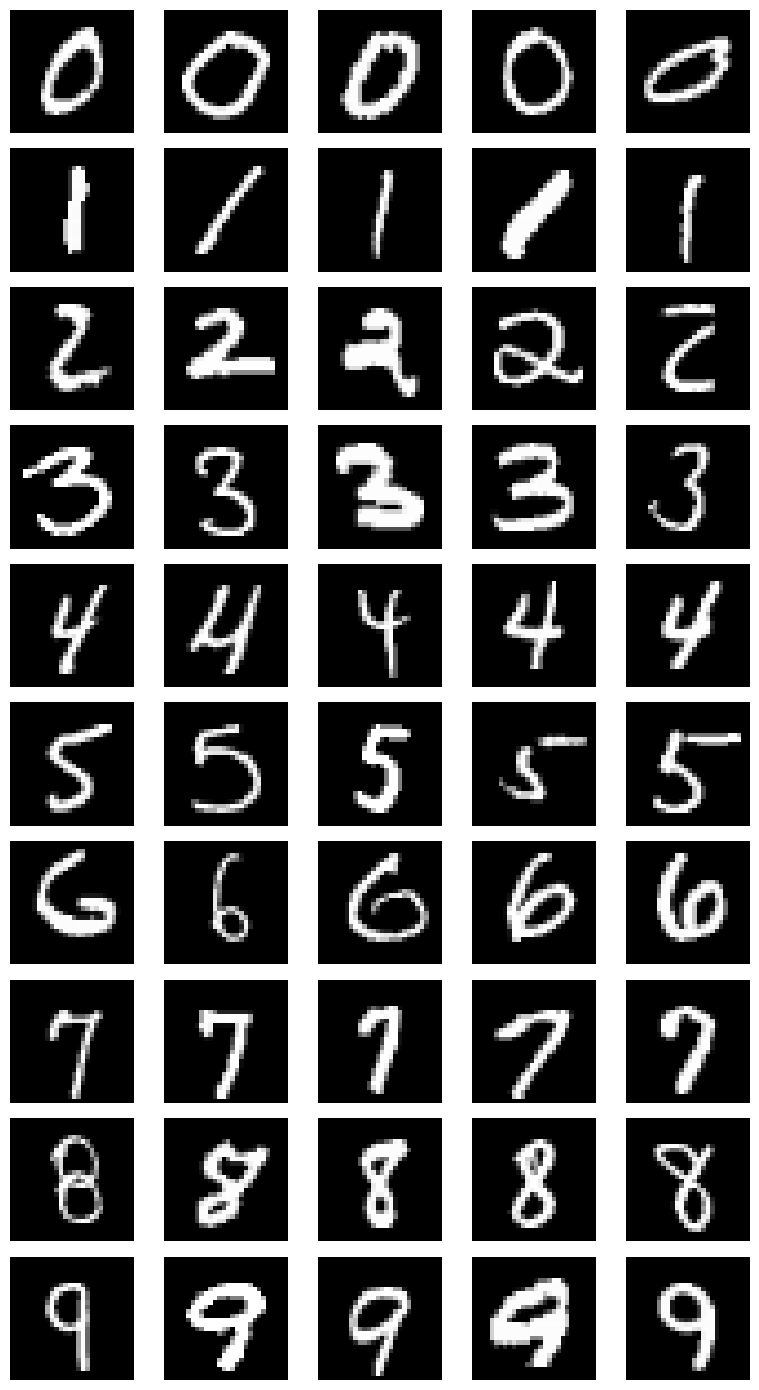

In [7]:
#Extract labels by indexing the initial dataset with the training_indices. We use numpy array for ease of indexing.
labels = training_set_full.targets[training_indices].cpu().numpy()

########################## Subplot ##########################

#Create the grid.
figure , axes = plt.subplots(10, 5, figsize = (8, 14))

#Repeat ten times , since we got ten classes: 0-9.
for i in range(10):

    #Find indices where the label corresponds to class i.
    #Pick the five first.
    class_indices = np.where(labels == i)[0][ : 5]

    #Loop and enumerate through said indices.
    for j , k in enumerate(class_indices):

        #Map back to original dataset through training_indices (It should say image_index rather than indices but oops).
        image_indices = training_indices[k]

        #Fetch image and label from full dataset.
        image , label = training_set_full[image_indices]

        #Print using squeeze to remove channel dimensions.
        axes[i , j].imshow(image.squeeze(), cmap = "gray")
        axes[i , j].axis("off")

#Ensure neat printing.
plt.tight_layout()
plt.show()


### 2. Autoencoders.
#### - MLP Autoencoder : μοντέλο Melchior.
Ακολουθεί ο ορίσμός ενός MLP Autoencoder ως κλάση. Δεν απέδωσε πολύ ως αρχιτεκτονική.
##### Input:
Tensor μεγέθους [N , 1 , 28 , 28].
##### Output:
Tensor μεγέθους [Ν , 1 , 28 , 28] (ανακατασκευή).
##### Ορίσματα: 
compressed_dimension (μέγεθος του latent vector). 
##### Pipeline encoder: 
Δέχεται flattened vector. Προβάλει διαδοχικά τα δεδομένα σε όλο και μικρότερη διάσταση. Η τελική τους διάσταση είναι το compressed_dimension. Εργάζεται ως εξής: 784 -> 256 -> ReLU -> 128 -> ReLU -> compressed_dimension.
##### Pipeline decoder:
Δέχεται το latent vector. Παράγει ανακατασκευή σε μορφή flatenned vector. Εκτελεί την αντίστροφη διαδικασία. compressed_dimension -> 128 -> ReLU -> 256 -> ReLU -> 784 -> Sigmoid.
##### Pipeline του forward step:
Δέχεται ως δείγμα εικόνες. Εργάζεται ως εξής: reshape από [Ν , 1 , 28 , 28] σε [Ν , 748] -> encode σε διάσταση [Ν , compressed_dimension] -> decode σε [Ν , 784] -> rshape πάλι στο αρχικό [Ν , 1 , 28 , 28].

(Όπου Ν το batch size)

In [9]:
class Melchior(nn.Module):
    
    def __init__(self, compressed_dimension = 64):

        super().__init__()
       
        ########################## Encoder ##########################
        
        #nn.Sequential essentialy defines the internal pipeline.
        self.encoder = nn.Sequential(
            #Maps flatenned input to [N , 256].
            nn.Linear(28 * 28 , 256),
            #Batch normalization to stabilize activations during training.
            nn.BatchNorm1d(256),
            #Non-linear activation. Inplace set to true for memory efficiency.
            nn.ReLU(True),
            #Projection to [N , 128].
            nn.Linear(256 , 128),
            #Batch normalization again.
            nn.BatchNorm1d(128),
            #ReLU again.
            nn.ReLU(True),
            #Final projection to [N , latent dimension].
            nn.Linear(128 , compressed_dimension) 
        )

        ########################## Decoder ##########################
        
        self.decoder = nn.Sequential(
            #Projection to 128. Etc.
            nn.Linear(compressed_dimension , 128),
            #Batch normalization to stabilize decoding activations.
            nn.BatchNorm1d(128),
            nn.ReLU(True),
            nn.Linear(128 , 256),
            #Batch normalization again.
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256 , 28 * 28),
            #Sigmoid ensures outputs lie within [0,1], matching dataset pixel values.
            nn.Sigmoid()          
        )

    ########################## Forward Step ##########################

    #Essentialy defines the working pipeline.
    def forward(self , x):
        #Flatten to [N , 784].
        x = x.view(x.size(0), -1) 
        #Encode.
        z = self.encoder(x) 
        #Decode.
        x_dec = self.decoder(z)
        #Reshape to original dimensions.
        x_dec = x_dec.view(x_dec.size(0), 1, 28, 28) 

        return x_dec


#### - Convolutional Autoencoder : μοντέλο Balthazar.
Αποτελεί τον καλύτερο από τους δύο. Επιλέχθηκε ως αρχιτεκτονική για την ανακατασκευή. 
##### Input:
Tensor μεγέθους [N , 1 , 28 , 28].
##### Output:
Tensor μεγέθους [Ν , 1 , 28 , 28] (ανακατασκευή).
##### Ορίσματα: 
channels (αριθμός καναλιών στο τελικό feature map) , base (αρχικό πλάτος καναλιού)
##### Pipeline encoder: 
Αποτελείται από τρία συνελικτικά blocks. Η συμπιεσμένη τελική αναπαράσταση έχει διαστάσεις [Ν , channels , 7 , 7]. Εργάζεται ως εξής: [N , 1 , 28 , 28] -> Συνέλιξη & Μείωση Διάστασης : [Ν , base , 14 , 14] -> BN -> ReLU -> Συνέλιξη & Μείωση Διάστασης : [Ν , 2 x base , 7 , 7] -> BN -> ReLU -> Συνέλιξη : [Ν , channels, 7 , 7] -> BN -> ReLU.
##### Pipeline decoder:
Ακολουθεί την ανάποδη διαδικασία. Η διάσταση ξεκινάει από [Ν , channels, 7 , 7] και καταλήγει σε [N , 1 , 28 , 28]. Χρησιμοποιείται η αντίστροφη συνέλιξη για τον σκοπό αυτό. Εργάζεται ως εξής: [Ν , channels, 7 , 7] -> Transpose Συνέλιξη: [Ν , 2 x base , 7 , 7] -> BN -> ReLU -> Transpose Συνέλιξη & αύξηση διάστασης : [Ν , base , 14 , 14] -> ΒΝ -> ReLU -> Transpose Συνέλιξη & αύξηση διάστασης : [Ν , base / 2 , 28 , 28] -> BN -> ReLU -> Συνέλιξη : [Ν , 1 , 28 , 28] -> Sigmoid.
##### Pipeline του forward step:
Απλώς καλεί encoder και decoder.

(Όπου Ν το batch size)

In [11]:
class Balthazar(nn.Module):

    def __init__(self, channels = 32 , base = 32):
        super().__init__()

        ########################## Encoder ##########################

        #nn.Sequencial essentialy defines the internal pipeline.
        self.encoder = nn.Sequential(
            #Convolution and downsampling to [N , base , 14 , 14].
            nn.Conv2d(1 , base , kernel_size = 3 , stride = 2 , padding = 1),       
            #Batch normalization for training stability.
            nn.BatchNorm2d(base),
            #ReLU activation. Inplace set to true for memory efficiency.
            nn.ReLU(True),

            #Convolution anda downsampling to [N , 2 * base , 7 , 7].
            nn.Conv2d(base , base * 2 , kernel_size = 3 , stride = 2 , padding = 1),
            nn.BatchNorm2d(base * 2),
            nn.ReLU(True),

            #Final convolution to the compressed feature map [N , channels , 7 , 7].
            #No downsampling used this time.
            nn.Conv2d(base * 2 , channels , kernel_size = 3 , stride = 1 , padding = 1), 
            nn.BatchNorm2d(channels),
            nn.ReLU(True)
        )

        ########################## Decoder ##########################

        #Inverse process: upsampling back to [N , 1 , 28 , 28] using Convolution Transpose..
        self.decoder = nn.Sequential(
            #Transpose convolution without increasing size. [N , channels , 7 , 7] -> [N , 2 * base , 7 , 7].
            nn.ConvTranspose2d(channels , base * 2 , kernel_size = 3 , stride = 1 , padding = 1),
            nn.BatchNorm2d(base * 2),
            nn.ReLU(True),

            #Transpose convolution and upsampling (is it a word? IDK): [N , 2 * base , 7 , 7] -> [N , base , 14 , 14].
            nn.ConvTranspose2d(base * 2 , base , kernel_size = 3 , stride = 2 , padding = 1 , output_padding = 1),
            nn.BatchNorm2d(base),
            nn.ReLU(True),

            #Transpose convolution and upsampling: [N , base , 14 , 14] -> [N , base / 2 , 28 , 28].
            nn.ConvTranspose2d(base , base // 2 , kernel_size = 3 , stride = 2 , padding = 1 , output_padding = 1),
            nn.BatchNorm2d(base // 2),
            nn.ReLU(True),

            #Final convolution to restore original shape and size. [N , base / 2 , 28 , 28] -> [N , 1 , 28 , 28].
            nn.Conv2d(base // 2 , 1 , kernel_size = 3 , padding = 1),
            
            #Sigmoid ensures outputs lie within [0,1], as found in MNIST.
            nn.Sigmoid()
        )

    ########################## Forward Step ##########################

    #Essentialy defines the working pipeline.
    def forward(self , x):
        #Encode to latent feature map [N , channels , 7 , 7].
        z = self.encoder(x)
        #Decode back to [N , 1 , 28 , 28].
        x_dec = self.decoder(z)
        return x_dec


### 3. CNN για αναγνώριση ψηφίων.
#### - Μοντέλο Kasper.
Είναι ενδιαφέρουσα προσθήκη στα πειράματα αργότερα. Η αρχιτεκτονική είναι αρκετά απλή. Δεν χρειάζεται κάτι παραπάνω, αφού σημειώνει εξαιρετικές επιδόσεις στην MNIST. Αποτελείται από δύο συνελικτικά block, με BN , ReLU και Max Pooling μετά από κάθε συνέλιξη. Γίνεται και χρήση dropout. 
##### Pipeline feature extractor: 
Συνέλιξη (16 channels στο output) -> BN -> ReLU -> Max Pooling -> Συνέλιξη (32 channels στο output) -> BN -> ReLU -> Max Pooilng. 
##### Pipeline classifier: 
Flatten -> εφαρμογή dropout (απενεργοποίηση νευρώνων) -> Linear FC Hidden Layer (128 outputs) -> ReLU -> Linear FCL (10 outputs).

In [13]:
class Kasper(nn.Module):
    
    def __init__(self , dropout = 0.2):
        super().__init__()

        ########################## Feature Extractor ##########################

        #nn.Sequential essentialy defines the internal pipeline.
        self.features = nn.Sequential(
            #Convolution to [N , 16 , 28 , 28].
            nn.Conv2d(1 , 16 , kernel_size = 3 , padding = 1),
            #Batch normalization.
            nn.BatchNorm2d(16),
            #ReLU activation. Inplace set to true for memory efficiency.
            nn.ReLU(True),
            #Max pooling 28x28 -> 14x14.
            nn.MaxPool2d(2) ,                             

            #Convolution to [N , 32 , 14 , 14].
            nn.Conv2d(16 , 32 , kernel_size = 3, padding = 1),
            #BN
            nn.BatchNorm2d(32),
            #ReLU
            nn.ReLU(True),
            #Downsampling again: 14x14 -> 7x7.
            nn.MaxPool2d(2),                             
        )

        ########################## Classifier ##########################

        self.classifier = nn.Sequential(
            #Flatten to [N , 32 * 7 * 7].
            nn.Flatten(),
            #Dropout regularization (randomly disables neurons during training).
            nn.Dropout(dropout),
            #Fully connected hidden layer to [N , 128].
            nn.Linear(32 * 7 * 7 , 128),
            nn.ReLU(True),
            #Final FCL to [N , 10]. Outputs scores for each class.
            nn.Linear(128 , 10)                            
        )

    ########################## Forward Step ##########################

    #Essentialy defines the working pipeline.
    def forward(self , x):
        #Extract convolutional features.
        x = self.features(x)
        #Classify.
        x = self.classifier(x)
        return x


### 4. PCA για reconstruction.
#### - Μοντέλο Eva.
Ορίζεται ακόμα μια φορά ως κλάση για ευκολία. Δεν έχουμε pipeline εντός της κλάσης στην προκειμένη περίπτωση. Εφαρμόζεται εξωτερικά αργότερα. Οι μέθοδοι δεν έχουν αυστηρή σειρά εντός της κλάσης.
##### Μέθοδοι:
Fit: PCA fit σε ένα batch εικόνων.
Reconstruct: προβολή σε διάνυσμα διάστασης [Ν , n_componets] και έπειτα ανακατασκευή στις αρχικές διαστάσεις.
MSE: υπολογισμός MSE μεταξύ αρχικών δειγμάτων και ανακατασκευών.
Explained_Variance: υπολογισμός του variance percentage που εξηγείται από τα δεδομένα components.
Components: επιστρέφει απλώς τα components

In [15]:
class Eva:
     
    def __init__(self , n_components , random_state = 42):
        ########################## Initialization ##########################

        #Number of principal components.
        #Essentially the number of latent dimensions.
        self.n_components = n_components
        #Set random seed for reproducibility.
        self.random_state = random_state
        #Internal PCA object.
        self.pca = PCA(n_components = n_components , random_state = random_state)
        #Flag to ensure that PCA attributes aren't called before fitting.
        self.fitted = False

    ########################## Model Fit Method ##########################

    #Fit PCA on the input data.
    #Learns the directions of maximum variance.
    def Fit(self , images):
        #Images expected as flatenned vectors. [N , 784]. 
        self.pca.fit(images)
        self.fitted = True
        return self

    ########################## Reconstruction  ##########################

    #Compress and reconstruct back using inverse transform.
    def Reconstruct(self , fitted_images):
        #Project images to lower dimension. [N , 785] -> [N , n_components].
        z = self.pca.transform(fitted_images)
        #Project back to original space: [N , n_components] -> [N , D].
        reconstructed = self.pca.inverse_transform(z)
        return reconstructed

    ########################## MSE - Loss ##########################

    #Compute MSE between input and PCA reconstruction.
    def MSE(self, fitted_images):
        reconstructed = self.Reconstruct(fitted_images)
        return float(np.mean((reconstructed - fitted_images) ** 2))

    ########################## PCA Metrics ##########################

    @property
    def Explained_Variance(self):
        #Return preserved variance percentage through SickitLearn's built-in method.
        #Metric for information preservation.
        #This attribute returns a 1-D array of length n_components. Each element corresponds to the variance 
        #that is expressed by each component. Thus the sum part.
        if not self.fitted:
            return None
        return float(self.pca.explained_variance_ratio_.sum())

    @property
    def Components(self):
        #Return number of components used after fitting.
        if not self.fitted:
            return None
        return int(self.pca.n_components_)


### 5. Training Models.
#### - Training Autoencoders.
Η ακόλουθη συνάρτηση υλοποιεί την διαδικασία εκπαίδευσης για τους autoencoders. Οι παράγοντες που μπορούμε να επιλέξουμε μέσω των ορισμάτων είναι: 
1. Tο μοντέλο
2. Tο αρχικό learning rate
3. O αριθμός των Training epochs
4. Tο training_dataloader
5. Tο next digit flag

Το validation dataloader είναι hard coded. Η συνάρτηση δεν το δέχεται όρισμα, άρα πρέπει να υπάρχει ως global μεταβλητή. Επίσης hardcoded είναι:
1. Tο loss criterion. Επιλέγουμε το MSE μεταξύ input και output pixels.
2. Ο optimizer. Ορίσαμε τον Adam.
3. Ο scheduler. Δουλεύουμε με τον ReduceLROnPlateau. Είναι ένας προσαρμοστικός scheduler που μειώνει το lr όταν ανιχνεύσει στασιμότητα στην βελτίωση του μοντέλου. Θέσαμε το patience = 0 και threshold 10^-4. Αυτό σημαίνει πως επεμβαίνει όταν το loss δεν βελτιωθεί κατά threshold για ένα epoch. Έχει επίσης 1 epoch cooldown και κατώτατο learning rate για να αποφύγουμε την αδρανοποίηση του μοντέλου. Επιλέχθηκε επειδή είναι σχεδόν "fire and forget".

Η διαδικασία εκπαίδευσης είναι όμοια με αυτή που είχαμε δει σε προηγούμενα παραδοτέα για τα ΝΝ. Forward Pass -> Υπολογισμός Loss -> Back Propagation -> Weight Updates μέσω Optimizer Step -> Υπολογισμός Epoch Loss. "Τρέχει" σε δύο modes, αναλόγα με το εάν θέλουμε ανακατασκευή του input ή του επόμενου ψηφίου (επιλέγουμε μέσω του next_digit flag). Στην πρώτη περίπτωση το loss υπολογίζεται σε σχέση με την αρχική εικόνα. Στην δεύτερη σε σχέση με ψηφίο της "επόμενης" κλάσης. Για να επιτευχθεί η διαδικασία χρειάζεται εισαγωγή τροποποιημένου training dataloader που θα δούμε στην συνέχεια. Το validation_dataloader πρέπει επίσης να τροποποιηθεί εξωτερικά.

Εκτός του συνηθισμένου training & validation loss, υπολογίζεται και τρίτη καμπύλη. Πρόκειται για το training loss με το μοντέλο να είναι σε evaluation mode. Στην πράξη διαφέρει ελάχιστα από το κλασσικό training loss, αλλά ήταν ενδιαφέρουσα προσθήκη.

Τέλος, επιστρέφεται dictionary με την επίδοση του μοντέλου.

In [17]:
def Train_Autoencoder(model , lr , num_epochs , training_dataloader , next_digit = False):

    ########################## Setup ##########################

    #Define loss criterion (pixel-wise MSE).
    criterion = nn.MSELoss()
    
    #Initialize Adam optimizer, while setting the specified lr.
    optimizer = torch.optim.Adam(model.parameters() , lr = lr)
    
    #Initialize scheduler. 
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer , mode="min" , factor = 0.5 , patience = 0 ,
        threshold = 1e-4 , threshold_mode = "abs" , cooldown = 1 , min_lr = 1e-6
    )

    #Initialize best loss , state and epoch with dummy values.
    best_validation_loss = float("inf")
    best_state = None
    best_epoch = None
    
    #Prealocate learning curves.
    training_losses = []
    training_losses_eval = []
    validation_losses = []
    learning_rates = []
    
    start = time.time()
    
    ########################## Training Loop ##########################
    
    for epoch in range(1 , num_epochs + 1):
    
        #Set model to training mode (active dropout and BN updates).
        model.train()
        training_loss = 0.0

        #If next_digit flag is on, train on next digit target.
        if next_digit:
            for image , target , _ in training_dataloader:
                #Zero gradients.
                optimizer.zero_grad()
                #Forward pass.
                x_dec = model(image)
                #Compute reconstruction loss against provided target.
                loss = criterion(x_dec , target)
                #Backpropagate.
                loss.backward()
                #Update weights.
                optimizer.step()
                #Calculate accumulative weighted loss.
                training_loss += loss.item() * image.size(0)

        #Else train in reconstruction mode. Now the target is the image itself.
        #Repetitive commments are skipped.
        else:
            for image , _ in training_dataloader:
                optimizer.zero_grad()
                x_dec = model(image)
                #Compute reconstruction loss against input.
                loss = criterion(x_dec, image)
                loss.backward()
                optimizer.step()
                training_loss += loss.item() * image.size(0)
    
        #Calculate average epoch loss and append to losses list.
        epoch_training_loss = training_loss / len(training_dataloader.dataset)
        training_losses.append(epoch_training_loss)
    
        ########################## Training Evaluation ##########################
    
        #Switch to evaluation mode (disable dropout, freeze BN ).
        model.eval()
        training_loss_eval = 0.0

        #Disable gradient tracking for evaluation.
        with torch.no_grad():

            #If next image, evaluate loss with next digit target.
            if next_digit:
                for image , target , _ in training_dataloader:
                    #Just the reconstruction and loss calculation steps are active in training evaluation mode.
                    x_dec = model(image)
                    loss = criterion(x_dec , target)
                    training_loss_eval += loss.item() * image.size(0)

            #Plain reconstruction mode.
            #Repetitive comments are skipped.
            else:
                for image, _ in training_dataloader:
                    x_dec = model(image)
                    loss = criterion(x_dec, image)
                    training_loss_eval += loss.item() * image.size(0)

        #Calculate average epoch loss and append to losses list.
        epoch_training_loss_eval = training_loss_eval / len(training_dataloader.dataset)
        training_losses_eval.append(epoch_training_loss_eval)
        
        ########################## Validation Evaluation ##########################

        #Same exact process but using the validation_dataloader.
        #Validation dataloader is hard-coded within the model and thus must be defined properly outside.
        validation_loss = 0.0
    
        with torch.no_grad():

            if next_digit:
                for image , target , _ in validation_dataloader:
                    x_dec = model(image)
                    loss = criterion(x_dec , target)
                    validation_loss += loss.item() * image.size(0)

            else:
                for image , _ in validation_dataloader:
                    x_dec = model(image)
                    loss = criterion(x_dec , image)
                    validation_loss += loss.item() * image.size(0)
    
        #Compute average validation loss.
        epoch_validation_loss = validation_loss / len(validation_dataloader.dataset)
        validation_losses.append(epoch_validation_loss)

        ########################## Scheduler and Best Model ############################
        
        #Activate scheduler step.
        scheduler.step(epoch_validation_loss)
        
        #Store current learning rate after scheduler step.
        current_lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(current_lr)
    
        #Update best model state if validation improves.
        if epoch_validation_loss < best_validation_loss:
            best_validation_loss = epoch_validation_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
    
        #Print epoch summary.
        print(
            f"Epoch {epoch:02d} | "
            f"Train (during updates): {epoch_training_loss:.6f} | "
            f"Train-eval: {epoch_training_loss_eval:.6f} | "
            f"Val: {epoch_validation_loss:.6f}")
        
    ########################## Saving and Returning Results ##########################
        
    #Compute and print total training time in minutes.
    training_time = round((time.time() - start) / 60 , 2)
    print("Training time (minutes):", training_time)

    #Load best model weights.
    if best_state is not None:
        model.load_state_dict(best_state)

    #Store results in a single dictionary for later plotting and reporting.
    results = {
        "training_losses": training_losses,
        "training_losses_eval": training_losses_eval,
        "validation_losses": validation_losses,
        "best_validation_loss": best_validation_loss,
        "best_epoch": best_epoch,
        "training_time": training_time,
        "lr": lr ,
        "num_epochs": num_epochs,
        "learning_rates" : learning_rates , 
        "model_name": model.__class__.__name__}

    return model , best_state , results


#### - Training Classifier (CNN).
Η ακόλουθει συνάρτηση υλοποιεί την εκπαίδευση του CNN (μοντέλου Kasper). Δεν διαφέρει πολύ σε δομή από την αντίστοιχη συνάρτηση του δεύτερου παδαροτέου. Είναι ένα cleaner version. Εισάγουμε ως ορίσματα:
1. Το μοντέλο
2. Το αρχικό LR
3. Το Weight Decay του Adam
4. Αριθμό από epochs
5. training & validation dataloaders

Έχουν επιλεγεί σταθερά: 
1. Adam
2. Cross Entropy Loss σαν κριτήριο
3. ReduceLROnPlateu scheduler, αυτή την φορά λιγότερο παρεμβατικός.

Για την εκπαίδευση και την αξιολόγηση ακολουθείται η γνωστή διαδικασία.

In [19]:
def Train_Classifier(model, lr, weight_decay , num_epochs, training_dataloader, validation_dataloader):

    ########################## Setup ##########################

    #Define classification loss (cross-entropy on logits).
    criterion = nn.CrossEntropyLoss()
    #Initialize Adam optimizer and set lr and weight decay.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr , weight_decay = weight_decay)
    #Initialize scheduler and reduce lr when validation loss plateaus.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer , mode = "min" , factor = 0.5, patience = 1)

    #Initialize best accuracy , state and epoch with dummy values.
    best_validation_accuracy = 0.0
    best_state = None
    best_epoch = None

    #Prealocate learning curves.
    training_accuracies = []
    validation_accuracies = []
    training_losses = []
    validation_losses = []

    start = time.time()

    ########################## Training Loop ##########################

    for epoch in range(1, num_epochs + 1):

        ########################## Training Step ##########################

        #Set model to training mode (active dropout and BN updates).
        model.train()
        correct = 0
        total = 0
        running_loss = 0.0

        for images, labels in training_dataloader:
            #Zero gradients.
            optimizer.zero_grad()
            #Forward pass and compute class scores (logits).
            scores = model(images)
            #Compute classification loss.
            loss = criterion(scores, labels)
            #Backpropagate and update weights.
            loss.backward()
            optimizer.step()

            #Accumulate weighted loss.
            running_loss += loss.item() * images.size(0)
            #Compute predictions and update accuracy counters.
            predictions = scores.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        #Compute average epoch training loss and accuracy.
        epoch_training_loss = running_loss / len(training_dataloader.dataset)
        epoch_training_accuracy = correct / total
        training_losses.append(epoch_training_loss)
        training_accuracies.append(epoch_training_accuracy)

        ########################## Validation Step ##########################

        #Switch to evaluation mode (disable dropout, freeze BN).
        model.eval()
        correct = 0
        total = 0
        running_loss = 0.0

        #Disable gradient tracking for validation.
        with torch.no_grad():
            for images, labels in validation_dataloader:
                scores = model(images)
                loss = criterion(scores, labels)

                running_loss += loss.item() * images.size(0)
                predictions = scores.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        #Compute average epoch validation loss and accuracy.
        epoch_validation_loss = running_loss / len(validation_dataloader.dataset)
        epoch_validation_accuracy = correct / total
        validation_losses.append(epoch_validation_loss)
        validation_accuracies.append(epoch_validation_accuracy)

        ########################## Scheduler and Best Model ##########################

        #Activate scheduler step using validation loss.
        scheduler.step(epoch_validation_loss)

        #Update best model state if validation accuracy improves.
        if epoch_validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = epoch_validation_accuracy
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        #Print epoch summary.
        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {epoch_training_loss:.4f}, acc: {epoch_training_accuracy:.4f} | "
            f"Val loss: {epoch_validation_loss:.4f}, acc: {epoch_validation_accuracy:.4f}"
        )

    ########################## Saving and Returning Results ##########################

    #Compute and print total training time in minutes.
    training_time = round((time.time() - start) / 60, 2)
    print("Training time (minutes):", training_time)
    print("Best epoch:", best_epoch, "| Best Val acc:", round(best_validation_accuracy, 4))

    #Restore best model weights.
    if best_state is not None:
        model.load_state_dict(best_state)

    #Store results in a single dictionary for later plotting and reporting.
    results = {
        "training_losses": training_losses,
        "validation_losses": validation_losses,
        "training_accuracies": training_accuracies,
        "validation_accuracies": validation_accuracies,
        "best_validation_accuracy": best_validation_accuracy,
        "best_epoch": best_epoch,
        "training_time_min": training_time,
        "lr": lr,
        "num_epochs": num_epochs,
        "model_name": model.__class__.__name__,
    }

    return model, best_state, results


### 6. Βοηθητικές συναρτήσεις.
#### - Plot Classifier Curves.
Δημιουργεί δύο γραφήματα, με δύο καμπύλες έκαστο. Training vs Validation Loss & Training vs Validation Accuracy. Εξάγει τις πληροφορίες από τα κατάλληλα sections του results dictionary που δεχεται ως όρισμα. 

In [21]:
def Plot_Classifier_Curves(results):

    #Extract values lists for plot creation. 
    training_losses = results["training_losses"]
    validation_losses = results["validation_losses"]
    training_accuracies = results["training_accuracies"]
    validation_accuracies = results["validation_accuracies"]

    epochs = range(1 , len(training_losses) + 1)

    #Plot losses.
    plt.figure(figsize = (7 , 4))
    plt.plot(epochs , training_losses , label = "Training loss")
    plt.plot(epochs , validation_losses , label = "Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("CNN Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #Plot accuracies.
    plt.figure(figsize = (7 , 4))
    plt.plot(epochs , training_accuracies , label = "Training accuracy")
    plt.plot(epochs , validation_accuracies , label = "Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("CNN Accuracy Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### - Plot Autoencoders Curves. 
Αντίστοιχη με την προηγούμενη. Παράγει μόνο ένα γράφημα (αφού στου AE έχουμε να κάνουμε μόνο με loss). Το διάγραμμα αυτό έχει επίσης τρεις καμπύλες, αφού περιλαμβάνει και το training eval loss.

In [23]:
def Plot_Autoencoder_Curves(results):

    #Extract values lists for plot creation. 
    training_losses = results["training_losses"]
    training_losses_eval = results["training_losses_eval"]
    validation_losses = results["validation_losses"]

    epochs = range(1 , len(training_losses) + 1)

    #Plot.
    plt.figure(figsize = (7 , 4))
    plt.plot(epochs , training_losses , label = "Training loss (during updates)")
    plt.plot(epochs , training_losses_eval , label = "Training loss (eval)")
    plt.plot(epochs , validation_losses , label = "Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Autoencoder Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### -Show Autoencoder Reconstructions.
Αρκετά χρήσιμη συνάρτηση για την αξιολόγηση των αποτελεσμάτων. Υποστηρίζει και τα δύο modes. Απλό reconstruction και next digit. Στην πρώτη περίπτωση παράγει plot που δείχνει την αρχική εικόνα και την ανακατασκευή της. Στην δεύτερη απεικονίζει την αρχικη εικόνα, την εικόνα-target από την επόμενη κλάση (όπως παρέχεται από τον dataloader) και τέλος το generated ψηφίο.
Δέχεται ως ορίσματα:
1. Το ΑΕ μοντέλο
2. Το dataloader
3. Το next_digit flag
4. Τον αριθμό των παραδειγμάτων που θέλουμε να τυπωθεί

Στο criterion ορίζουμε MSE. Αυτή την φορά όμως χρησιμοποιούμε το όρισμα reduction = "none". Έτσι μας μένουν τα MSE ανά δείγμα και όχι ο μέσος όρος τους. Καλούμε το μοντέλο για τις εικόνες του dataloader. Στην συνέχεια υπολογίζουμε MSEs ανά pixel και το ανάγουμε σε όλη την εικόνα παίρνοντας την μέση τιμή τους. Αποθηκεύουμε τα αποτελέσματα και καλούμε την βοηθητική συνάρτηση που περιέχεται για απεικόνιση δέκα καλύτερων και δέκα χειρότερων δειγμάτων. 

In [25]:
def Show_Autoencoder_Reconstructions(model , dataloader , next_digit = False , num_examples = 10):

    ########################## Setup ##########################

    #Set model to evaluation mode.
    model.eval()

    #Collect all inputs , targets , reconstructions and per-sample errors.
    all_images = []
    all_targets = []
    all_reconstructions = []
    all_errors = []

    #Define MSE per pixel by setting reduction = "none".
    #Do this only here because compute persample errors in order to rank best and worst reconstructions.
    #In training we use mean ( the default) reduction to obtain a single loss valeu for backpropagation.
    criterion = nn.MSELoss(reduction = "none")

    ########################## Forward Pass on Passed Dataloader ##########################

    #Disable gradient tracking.
    with torch.no_grad():

        for batch in dataloader:

            #Read batch depending on next_digit flag.
            if next_digit:
                images , targets , _ = batch
            else:
                images , _ = batch
                #Set targets equal to inputs in plain reconstruction mode.
                targets = images

            #Reconstruct images.
            reconstructions = model(images)

            #Compute per-pixel MSE.
            per_pixel = criterion(reconstructions , targets)
            #Reduce to per-sample MSE by averaging over all pixels.
            per_sample = per_pixel.view(per_pixel.size(0) , -1).mean(1)

            #Append to corresponding lists.
            all_images.append(images)
            all_targets.append(targets)
            all_reconstructions.append(reconstructions)
            all_errors.append(per_sample)

    #Concatenate all batches into a single tensor per category.
    #The Torch equivelant of NUmpy's .concat() method.
    all_images = torch.cat(all_images , dim = 0)
    all_targets = torch.cat(all_targets , dim = 0)
    all_reconstructions = torch.cat(all_reconstructions , dim = 0)
    all_errors = torch.cat(all_errors , dim = 0)

    ########################## Plotting Helper Function ##########################

    def Plot_Block(title , indices):

        #Set rows depending on mode. We need one more for the next digit mode.
        if next_digit:
            rows = 3
        else:
            rows = 2

        #Create subplot.
        figure , axes = plt.subplots(rows , num_examples , figsize = (2 * num_examples , 2 * rows))
        figure.suptitle(title , fontsize = 14)

        for j , index in enumerate(indices):

            #Extract single samples and remove channel dimension.
            x = all_images[index].squeeze(0)
            y = all_targets[index].squeeze(0)
            xhat = all_reconstructions[index].squeeze(0)
            #Extract sample MSE for title.
            err = float(all_errors[index])

            #Plot input and reconstruction for plain reconstruction mode.
            if rows == 2:
                axes[0 , j].imshow(x , cmap = "gray")
                axes[0 , j].axis("off")
                axes[0 , j].set_title(f"MSE : {err:.5f}" , fontsize = 9)

                axes[1 , j].imshow(xhat , cmap = "gray")
                axes[1 , j].axis("off")

                #Add row labels only to first colunm.
                if j == 0:
                    axes[0 , j].set_ylabel("Input" , rotation = 0 , labelpad = 30 , va = "center")
                    axes[1 , j].set_ylabel("Reconstruct" , rotation = 0 , labelpad = 30 , va = "center")

            #Plot input , target and reconstruction for next_digit mode.
            else:
                axes[0 , j].imshow(x , cmap = "gray")
                axes[0 , j].axis("off")
                axes[0 , j].set_title(f"MSE : {err:.5f}" , fontsize = 9)

                axes[1 , j].imshow(y , cmap = "gray")
                axes[1 , j].axis("off")

                axes[2 , j].imshow(xhat , cmap = "gray")
                axes[2 , j].axis("off")

                if j == 0:
                    axes[0 , j].set_ylabel("Input" , rotation = 0 , labelpad = 30 , va = "center")
                    axes[1 , j].set_ylabel("Target" , rotation = 0 , labelpad = 30 , va = "center")
                    axes[2 , j].set_ylabel("Reconstruction" , rotation = 0 , labelpad = 30 , va = "center")

        #Tighten layout and show figure.
        plt.tight_layout()
        plt.show()

    ########################## Select Indices ##########################

    #Limit number of plotted examples to dataset size.
    example_count = min(num_examples , len(all_errors))
    #Select first examples in the same order they are found in the dataset.
    indices_examples = list(range(example_count))

    #Sort indices by reconstruction error.
    sorted_indices = torch.argsort(all_errors)
    #Select best and worst reconstructions.
    indices_best = sorted_indices[:example_count].tolist()
    indices_worst = sorted_indices[-example_count:].tolist()

    ########################## Plot Blocks ##########################

    #Plot a few standard examples.
    Plot_Block("Examples of Input vs Reconstruction" , indices_examples)
    #Plot best reconstructions by MSE.
    Plot_Block("Best Reconstructions " , indices_best)
    #Plot worst reconstructions by MSE.
    Plot_Block("Worst Reconstructions " , indices_worst)


#### - Evaluate Autoencoder.
Απλή συνάρτηση που αξιολογεί την επίδοση ΑΕ σε κάποιον dataloader με κριτήριο MSE. Επιστρέφει το loss και το inference time (λανθασμένα καλείται fit time εντός). Σχεδιάστηκε για να δεχτεί το test set, οπότε θεωρεί ήδη εκπαιδευμένο μοντέλο.

In [27]:
def Evaluate_Autoencoder(model , dataloader):

    ########################## Setup ##########################
    #Set model to evaluation mode and define criterion as MSE.
    model.eval()
    criterion = nn.MSELoss()
    total_loss = 0.0

    ########################## Evaluation Loop ##########################
    
    start = time.time()
    #Disable gradient tracking.
    with torch.no_grad():
        for images , _ in dataloader:
            #Decode, compute loss and accumulate like before.
            x_dec = model(images)
            loss = criterion(x_dec , images)
            total_loss += loss.item() * images.size(0)
    #Calculate average loss per sample.
    test_loss = total_loss / len(dataloader.dataset)
    fit_time = np.round((time.time() - start) , 2)
    return test_loss , fit_time

#### - Flatten Images.
Το PCA προϋποθέτει flattened vectors. Αυτό ακριβώς κάνει η ακόλουθη συνάρτηση. Επιστρέφει numpy array με τις flattened εικόνες του dataloader.

In [29]:
def Flatten_Images(dataloader):

    images = []

    #Iterate thrpugh images in dataloader and reshape.
    with torch.no_grad():
        for image , _ in dataloader:
            image = image.view(image.size(0) , -1)
            images.append(image)

    images = torch.cat(images , dim = 0)
    return images.numpy()

### 7. Εκαπαίδευση Μοντέλων και Tuning.
Ακολουθούν δοκιμές για την επιλογη παραμέτρων του CNN και των ΑΕ. Θυμίζουμε πως εκτυπώνουμε τα αποτελέσματα κάθε epoch και επιστρέφουμε/αποθηκεύουμε το μοτνέλο με τα updated weights, το results dictionary και τα βάρη της καλύτερης επίδοσης. Θυμίζουμε επίσης πως κρίνουμε το best state με βάση το validation accuracy/loss. Τέλος, εκτυπώνουμε στην κονσόλα και το LR κάθε epoch για να παρακολουθήσουμε την επίδραση του Scheduler.

#### - Εκπαίδευση  Μοντέλου Kasper (CNN).
##### Setup:
1. Αρχικό LR = 10^-3
2. Weight Decay = 10^-4
3. Epochs = 20
##### Αποτελέσματα:
Καλύτερο validation accuracy 99,26%. Εξαιρετική επίδοση. Δεν χρειάστηκε άλλο πείραμα, αν και είχαν γίνει μία-δύο ακόμα δοκιμές που δεν περιλαμβάνονται.

C:\Users\dimit\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train loss: 0.1761, acc: 0.9466 | Val loss: 0.0730, acc: 0.9768
Epoch 02 | Train loss: 0.0643, acc: 0.9801 | Val loss: 0.0552, acc: 0.9826
Epoch 03 | Train loss: 0.0479, acc: 0.9848 | Val loss: 0.0428, acc: 0.9877
Epoch 04 | Train loss: 0.0399, acc: 0.9874 | Val loss: 0.0582, acc: 0.9807
Epoch 05 | Train loss: 0.0335, acc: 0.9887 | Val loss: 0.0381, acc: 0.9883
Epoch 06 | Train loss: 0.0287, acc: 0.9911 | Val loss: 0.0390, acc: 0.9872
Epoch 07 | Train loss: 0.0265, acc: 0.9909 | Val loss: 0.0373, acc: 0.9893
Epoch 08 | Train loss: 0.0216, acc: 0.9930 | Val loss: 0.0397, acc: 0.9873
Epoch 09 | Train loss: 0.0221, acc: 0.9927 | Val loss: 0.0337, acc: 0.9902
Epoch 10 | Train loss: 0.0196, acc: 0.9933 | Val loss: 0.0442, acc: 0.9878
Epoch 11 | Train loss: 0.0184, acc: 0.9939 | Val loss: 0.0412, acc: 0.9879
Epoch 12 | Train loss: 0.0102, acc: 0.9965 | Val loss: 0.0272, acc: 0.9917
Epoch 13 | Train loss: 0.0082, acc: 0.9972 | Val loss: 0.0336, acc: 0.9889
Epoch 14 | Train loss: 0.

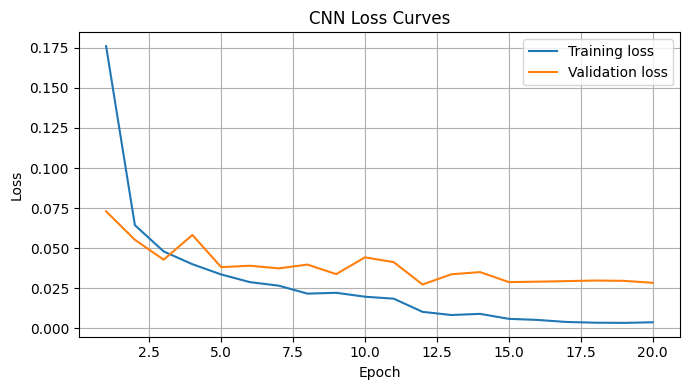

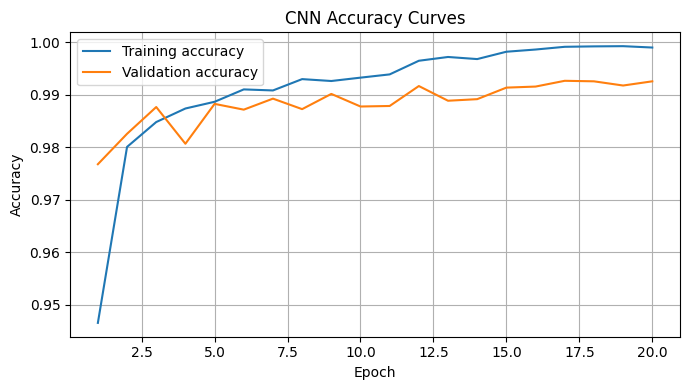

In [135]:
Kasper_model = Kasper()

Kasper_model , Kasper_best_state , Kasper_results = Train_Classifier(model = Kasper_model , lr = 1e-3 , 
                                                                    weight_decay = 1e-4 , num_epochs = 20 , 
                                                                     training_dataloader = training_dataloader , 
                                                                     validation_dataloader = validation_dataloader)
Plot_Classifier_Curves(Kasper_results)

#Save results for ease of use.
torch.save(Kasper_results , "Kasper_results.pt")
torch.save(Kasper_best_state , "Kasper_best_state.pt")

#### - Εκπαίδευση  Μοντέλου Melchior για Reconstruction (AE).
Ακολουθούν τρία όμοια runs. Το μόνο που αλλάζει είναι το μέγεθος του latent dimension.
##### Setup:
1. compresses_dimension = 32 , 64 και 128 αντίστοιχα.
2. Αρχικό LR = 10^-3
3. Epochs = 30
##### Αποτελέσματα:
Καλύτερο validation loss 0.004483 για μέγεθος 132. Χαμηλή επίδοση, αλλά είναι κάτι αναμενόμενο για MLP AE. Δεν φαίνεται πως περισσότερα epochs βοηθούν. Δεν κρίθηκε επίσης αναγκαία η χρήση weight decay στον optimizer καθώς δεν υπάρχουν ενδείξεις overfitting. Τέλος, η αύξηση του latent dimension δίνει trivial gains. 

In [109]:
Melchior32_model = Melchior(compressed_dimension = 32)

Melchior32_model , Melchior32_best_state , Melchior32_results = Train_Autoencoder(model = Melchior32_model , lr = 1e-3 , num_epochs = 30,
                                                                                  training_dataloader = training_dataloader , next_digit = False)

torch.save(Melchior32_results , "Melchior32_results.pt")
torch.save(Melchior32_best_state , "Melchior32_best_state.pt")

print(Melchior32_results["learning_rates"])

C:\Users\dimit\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train (during updates): 0.031599 | Train-eval: 0.015900 | Val: 0.015989
Epoch 02 | Train (during updates): 0.014093 | Train-eval: 0.011315 | Val: 0.011486
Epoch 03 | Train (during updates): 0.011212 | Train-eval: 0.009488 | Val: 0.009715
Epoch 04 | Train (during updates): 0.009855 | Train-eval: 0.008466 | Val: 0.008766
Epoch 05 | Train (during updates): 0.009083 | Train-eval: 0.007776 | Val: 0.008119
Epoch 06 | Train (during updates): 0.008504 | Train-eval: 0.007321 | Val: 0.007697
Epoch 07 | Train (during updates): 0.008081 | Train-eval: 0.007066 | Val: 0.007459
Epoch 08 | Train (during updates): 0.007752 | Train-eval: 0.006730 | Val: 0.007149
Epoch 09 | Train (during updates): 0.007496 | Train-eval: 0.006537 | Val: 0.006971
Epoch 10 | Train (during updates): 0.007279 | Train-eval: 0.006293 | Val: 0.006738
Epoch 11 | Train (during updates): 0.007113 | Train-eval: 0.006138 | Val: 0.006604
Epoch 12 | Train (during updates): 0.006969 | Train-eval: 0.006015 | Val: 0.006485
Epoc

In [110]:
Melchior64_model = Melchior(compressed_dimension = 64)

Melchior64_model , Melchior64_best_state , Melchior64_results = Train_Autoencoder(model = Melchior64_model , lr = 1e-3 , num_epochs = 30,
                                                                                  training_dataloader = training_dataloader , next_digit = False)

torch.save(Melchior64_results , "Melchior64_results.pt")
torch.save(Melchior64_best_state , "Melchior64_best_state.pt")

print(Melchior64_results["learning_rates"])

Epoch 01 | Train (during updates): 0.030747 | Train-eval: 0.015159 | Val: 0.015252
Epoch 02 | Train (during updates): 0.013315 | Train-eval: 0.010594 | Val: 0.010794
Epoch 03 | Train (during updates): 0.010411 | Train-eval: 0.008829 | Val: 0.009097
Epoch 04 | Train (during updates): 0.009088 | Train-eval: 0.007676 | Val: 0.007990
Epoch 05 | Train (during updates): 0.008219 | Train-eval: 0.007069 | Val: 0.007397
Epoch 06 | Train (during updates): 0.007643 | Train-eval: 0.006551 | Val: 0.006899
Epoch 07 | Train (during updates): 0.007207 | Train-eval: 0.006194 | Val: 0.006580
Epoch 08 | Train (during updates): 0.006863 | Train-eval: 0.005886 | Val: 0.006278
Epoch 09 | Train (during updates): 0.006593 | Train-eval: 0.005633 | Val: 0.006043
Epoch 10 | Train (during updates): 0.006339 | Train-eval: 0.005444 | Val: 0.005854
Epoch 11 | Train (during updates): 0.006134 | Train-eval: 0.005246 | Val: 0.005653
Epoch 12 | Train (during updates): 0.005925 | Train-eval: 0.005067 | Val: 0.005484
Epoc

In [111]:
Melchior128_model = Melchior(compressed_dimension = 128)

Melchior128_model , Melchior128_best_state , Melchior128_results = Train_Autoencoder(model = Melchior128_model , lr = 1e-3 , num_epochs = 30,
                                                                                  training_dataloader = training_dataloader , next_digit = False)

torch.save(Melchior128_results , "Melchior128_results.pt")
torch.save(Melchior128_best_state , "Melchior128_best_state.pt")

print(Melchior128_results["learning_rates"])

Epoch 01 | Train (during updates): 0.030347 | Train-eval: 0.014856 | Val: 0.014955
Epoch 02 | Train (during updates): 0.013022 | Train-eval: 0.010261 | Val: 0.010468
Epoch 03 | Train (during updates): 0.010193 | Train-eval: 0.008559 | Val: 0.008841
Epoch 04 | Train (during updates): 0.008846 | Train-eval: 0.007502 | Val: 0.007829
Epoch 05 | Train (during updates): 0.008069 | Train-eval: 0.006840 | Val: 0.007200
Epoch 06 | Train (during updates): 0.007521 | Train-eval: 0.006478 | Val: 0.006847
Epoch 07 | Train (during updates): 0.007095 | Train-eval: 0.006026 | Val: 0.006411
Epoch 08 | Train (during updates): 0.006741 | Train-eval: 0.005744 | Val: 0.006133
Epoch 09 | Train (during updates): 0.006438 | Train-eval: 0.005522 | Val: 0.005921
Epoch 10 | Train (during updates): 0.006183 | Train-eval: 0.005268 | Val: 0.005669
Epoch 11 | Train (during updates): 0.005951 | Train-eval: 0.005054 | Val: 0.005454
Epoch 12 | Train (during updates): 0.005786 | Train-eval: 0.004973 | Val: 0.005372
Epoc

#### - Εκπαίδευση  Μοντέλου Balthazar για Reconstruction (Convolutional AE).
Ακολουθούν τρία runs. Κάνουμε pivot μεταξύ των setups ώστε να δούμε πως η κάθε επιλογή επηρεάζει την επίδοση. Δηλαδή, στα πρώτα κρατάμε σταθερή την παράμετρο base width και αυξάνουμε τα channels και για το τρίτο κρατάμε σταθερά channels και αυξάνουμε το base width.
##### Setup 1:
1. channels = 2 , base = 32.
2. Αρχικό LR = 10^-3
3. Epochs = 30

##### Setup 2:
1. channels = 3 , base = 32.
2. Αρχικό LR = 10^-3
3. Epochs = 30

##### Setup 3:
1. channels = 3 , base = 64.
2. Αρχικό LR = 10^-3
3. Epochs = 30

##### Αποτελέσματα:
Καλύτερο validation loss 0.000987 για channels = 2 , base = 64. Καλύτερη επίδοση. Αν και πάλι οι διαφορές μεταξύ των τριών setups δεν είναι πολύ αισθητές.

In [64]:
Balthazar98_32_model = Balthazar(channels = 2 , base = 32)

Balthazar98_32_model , Balthazar98_32_best_state , Balthazar98_32_results = Train_Autoencoder(model = Balthazar98_32_model , lr = 1e-3 , num_epochs = 30,
                                                                                  training_dataloader = training_dataloader , next_digit = False)

torch.save(Balthazar98_32_results , "Balthazar98_32_results.pt")
torch.save(Balthazar98_32_best_state , "Balthazar98_32_best_state.pt")

print(Balthazar98_32_results["learning_rates"])

C:\Users\dimit\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train (during updates): 0.015965 | Train-eval: 0.004457 | Val: 0.004465
Epoch 02 | Train (during updates): 0.003359 | Train-eval: 0.003466 | Val: 0.003482
Epoch 03 | Train (during updates): 0.002841 | Train-eval: 0.002647 | Val: 0.002665
Epoch 04 | Train (during updates): 0.002605 | Train-eval: 0.002380 | Val: 0.002399
Epoch 05 | Train (during updates): 0.002450 | Train-eval: 0.002321 | Val: 0.002337
Epoch 06 | Train (during updates): 0.002252 | Train-eval: 0.002289 | Val: 0.002306
Epoch 07 | Train (during updates): 0.002208 | Train-eval: 0.002133 | Val: 0.002151
Epoch 08 | Train (during updates): 0.002166 | Train-eval: 0.002348 | Val: 0.002366
Epoch 09 | Train (during updates): 0.002091 | Train-eval: 0.002010 | Val: 0.002031
Epoch 10 | Train (during updates): 0.002077 | Train-eval: 0.001990 | Val: 0.002012
Epoch 11 | Train (during updates): 0.002028 | Train-eval: 0.001984 | Val: 0.002006
Epoch 12 | Train (during updates): 0.002008 | Train-eval: 0.001966 | Val: 0.001989
Epoc

In [65]:
Balthazar147_32_model = Balthazar(channels = 3 , base = 32)

Balthazar147_32_model , Balthazar147_32_best_state , Balthazar147_32_results = Train_Autoencoder(model = Balthazar147_32_model , lr = 1e-3 , num_epochs = 30,
                                                                                  training_dataloader = training_dataloader , next_digit = False)

torch.save(Balthazar147_32_results , "Balthazar147_32_results.pt")
torch.save(Balthazar147_32_best_state , "Balthazar147_32_best_state.pt")

print(Balthazar147_32_results["learning_rates"])

Epoch 01 | Train (during updates): 0.012215 | Train-eval: 0.002771 | Val: 0.002775
Epoch 02 | Train (during updates): 0.002210 | Train-eval: 0.002057 | Val: 0.002067
Epoch 03 | Train (during updates): 0.001827 | Train-eval: 0.001739 | Val: 0.001750
Epoch 04 | Train (during updates): 0.001672 | Train-eval: 0.001993 | Val: 0.002001
Epoch 05 | Train (during updates): 0.001540 | Train-eval: 0.001444 | Val: 0.001457
Epoch 06 | Train (during updates): 0.001469 | Train-eval: 0.001440 | Val: 0.001453
Epoch 07 | Train (during updates): 0.001411 | Train-eval: 0.001371 | Val: 0.001384
Epoch 08 | Train (during updates): 0.001393 | Train-eval: 0.001350 | Val: 0.001364
Epoch 09 | Train (during updates): 0.001357 | Train-eval: 0.001329 | Val: 0.001344
Epoch 10 | Train (during updates): 0.001345 | Train-eval: 0.001316 | Val: 0.001330
Epoch 11 | Train (during updates): 0.001329 | Train-eval: 0.001300 | Val: 0.001314
Epoch 12 | Train (during updates): 0.001325 | Train-eval: 0.001305 | Val: 0.001320
Epoc

In [66]:
Balthazar147_64_model = Balthazar(channels = 3 , base = 64)

Balthazar147_64_model , Balthazar147_64_best_state , Balthazar147_64_results = Train_Autoencoder(model = Balthazar147_64_model , lr = 1e-3 , num_epochs = 30,
                                                                                  training_dataloader = training_dataloader , next_digit = False)

torch.save(Balthazar147_64_results , "Balthazar147_64_results.pt")
torch.save(Balthazar147_64_best_state , "Balthazar147_64_best_state.pt")

print(Balthazar147_64_results["learning_rates"])

Epoch 01 | Train (during updates): 0.008761 | Train-eval: 0.002022 | Val: 0.002037
Epoch 02 | Train (during updates): 0.001876 | Train-eval: 0.001730 | Val: 0.001742
Epoch 03 | Train (during updates): 0.001580 | Train-eval: 0.001453 | Val: 0.001468
Epoch 04 | Train (during updates): 0.001444 | Train-eval: 0.001345 | Val: 0.001363
Epoch 05 | Train (during updates): 0.001340 | Train-eval: 0.001359 | Val: 0.001377
Epoch 06 | Train (during updates): 0.001200 | Train-eval: 0.001193 | Val: 0.001213
Epoch 07 | Train (during updates): 0.001174 | Train-eval: 0.001126 | Val: 0.001148
Epoch 08 | Train (during updates): 0.001096 | Train-eval: 0.001062 | Val: 0.001083
Epoch 09 | Train (during updates): 0.001087 | Train-eval: 0.001095 | Val: 0.001117
Epoch 10 | Train (during updates): 0.001049 | Train-eval: 0.001021 | Val: 0.001044
Epoch 11 | Train (during updates): 0.001032 | Train-eval: 0.001016 | Val: 0.001039
Epoch 12 | Train (during updates): 0.001016 | Train-eval: 0.000997 | Val: 0.001021
Epoc

#### - Εκτύπωση Validation και Loss Curves.
Χρησιμοποιούμε την βοηθητική συνάρτηση για να εκτυπώσουμε τις καμπύλες εκπαίδευσης όλων των μοντέλων φορτώνοντας τα results dictionaries από τον δίσκο.

MLP Autoencoder , Latent Size 32


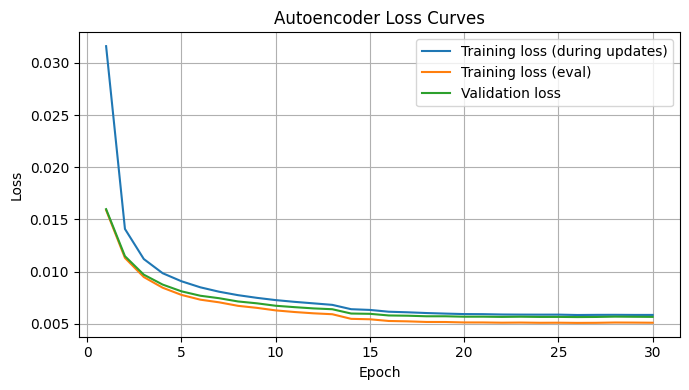

MLP Autoencoder , Latent Size 64


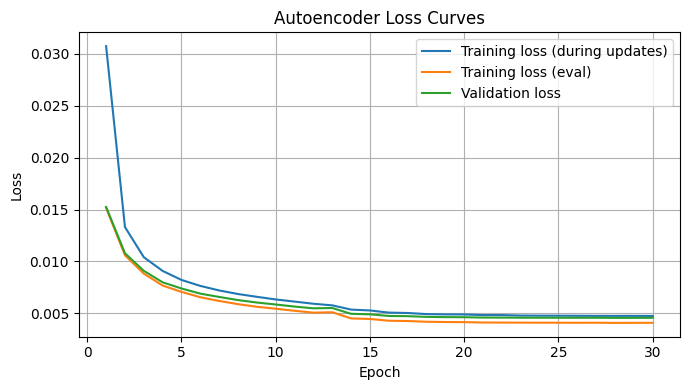

MLP Autoencoder , Latent Size 128


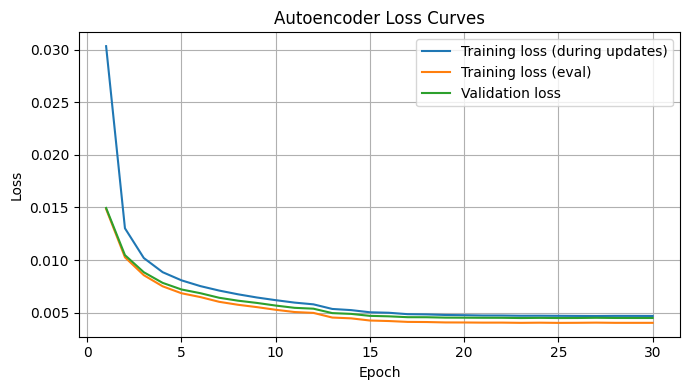

Convolutional Autoencoder , Latent Size 98 , Base Feature Channels 32


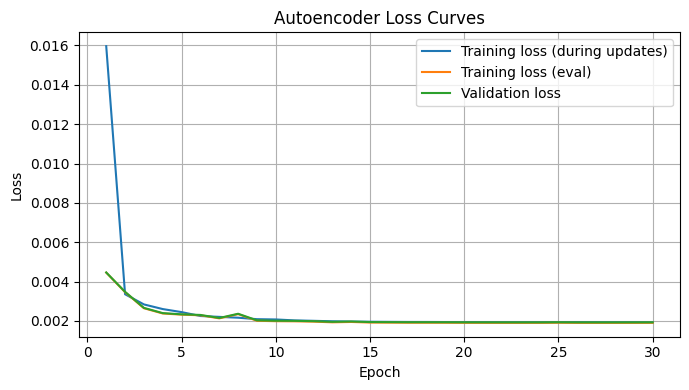

Convolutional Autoencoder , Latent Size 147 , Base Feature Channels 32


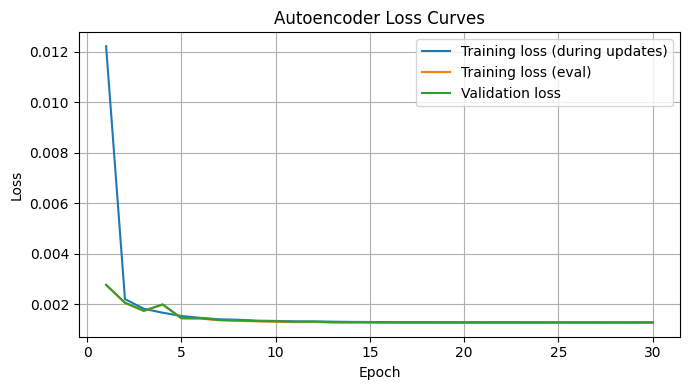

Convolutional Autoencoder , Latent Size 147 , Base Feature Channels 64


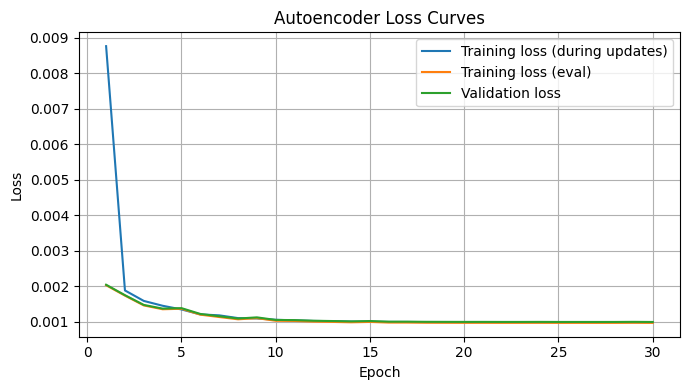

In [112]:
Melchior32_results = torch.load("Melchior32_results.pt" , map_location = "cpu")
Melchior64_results = torch.load("Melchior64_results.pt" , map_location = "cpu")
Melchior128_results = torch.load("Melchior128_results.pt" , map_location = "cpu")

Balthazar98_32_results = torch.load("Balthazar98_32_results.pt" , map_location = "cpu")
Balthazar147_32_results = torch.load("Balthazar147_32_results.pt" , map_location = "cpu")
Balthazar147_64_results = torch.load("Balthazar147_64_results.pt" , map_location = "cpu")

print("MLP Autoencoder , Latent Size 32")
Plot_Autoencoder_Curves(Melchior32_results)

print("MLP Autoencoder , Latent Size 64")
Plot_Autoencoder_Curves(Melchior64_results)

print("MLP Autoencoder , Latent Size 128")
Plot_Autoencoder_Curves(Melchior128_results)

print("Convolutional Autoencoder , Latent Size 98 , Base Feature Channels 32")
Plot_Autoencoder_Curves(Balthazar98_32_results)

print("Convolutional Autoencoder , Latent Size 147 , Base Feature Channels 32")
Plot_Autoencoder_Curves(Balthazar147_32_results)

print("Convolutional Autoencoder , Latent Size 147 , Base Feature Channels 64")
Plot_Autoencoder_Curves(Balthazar147_64_results)

### 8. Αξιολόγηση Μοντέλων και Συγκρίσεις.

#### - Αξιολόγηση ΑΕs στο Test Set.
Στα δύο ακόλουθα cells εισάγουμε το test set και αξιολογούμε την επίδοση του καλύτερου MLP (Melchior 128) και του καλύτερου Convolutional Autoencoder (Balthazar 3 , 64). Καλούμε την Show_Autoencoder_Reconstructions για οπτική επιθεώρηση των αποτελεσμάτων. 
##### Αποτελέσματα:
Ο ConvAE υπερισχύει. Το loss που καταγράφουμε δεν διαφέρει πολύ από το αναμενόμενο. Τα οπτικά αποτελέσματα ανακατασκευής είναι καλύτερα στην περίπτωση του μοντέλου Balthazar (Conv AE). Ακόμα και οι χειρότερες ανακατασκευές δεν διαφέρουν πολύ από τις αρχικές εικόνες.

In [45]:
transform = transforms.ToTensor()

test_set = datasets.MNIST(root = root , train = False , download = True , transform = transform)
test_dataloader = DataLoader(test_set , batch_size = 256 , shuffle = False , num_workers = 2)

Melchior128 test MSE: 0.004384
Melchior128 fit time (s): 7.25


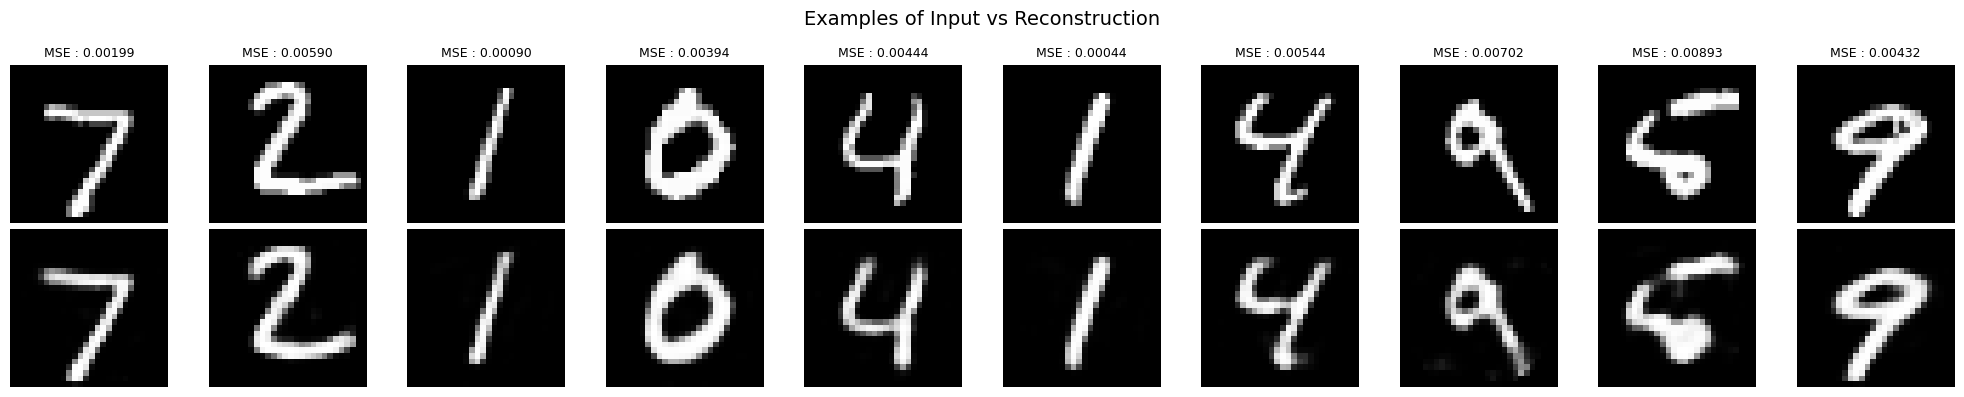

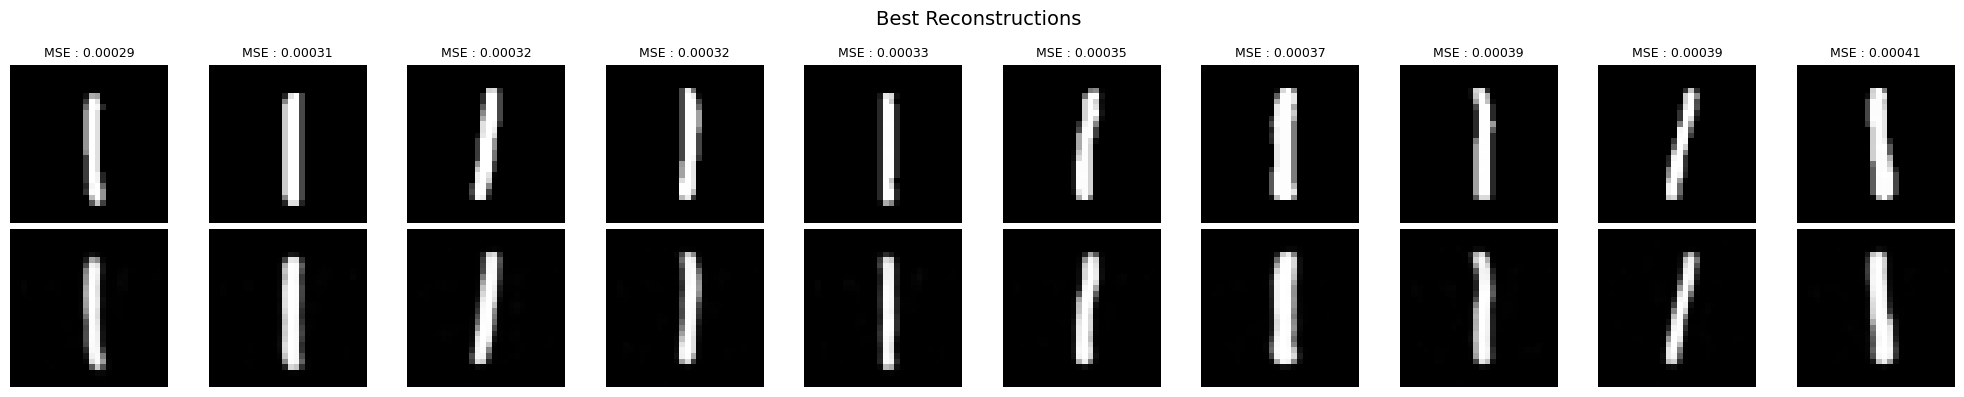

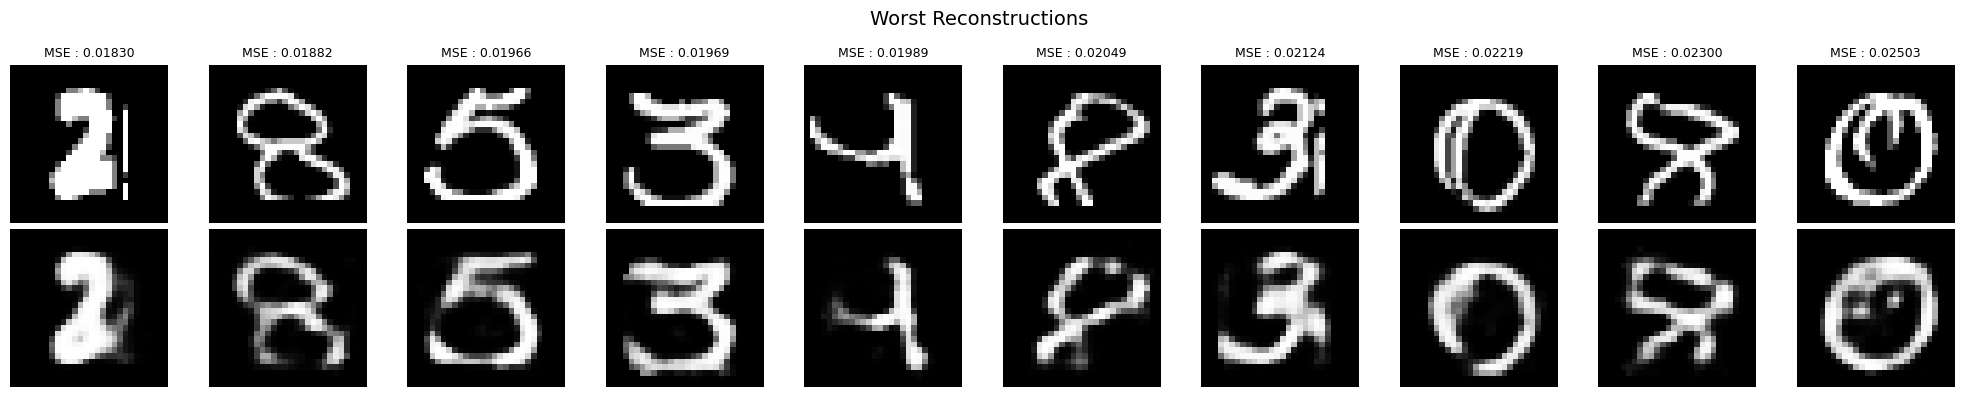

Balthazar147_64 test MSE: 0.000961
Balthazar47_64 fit time (s): 8.7


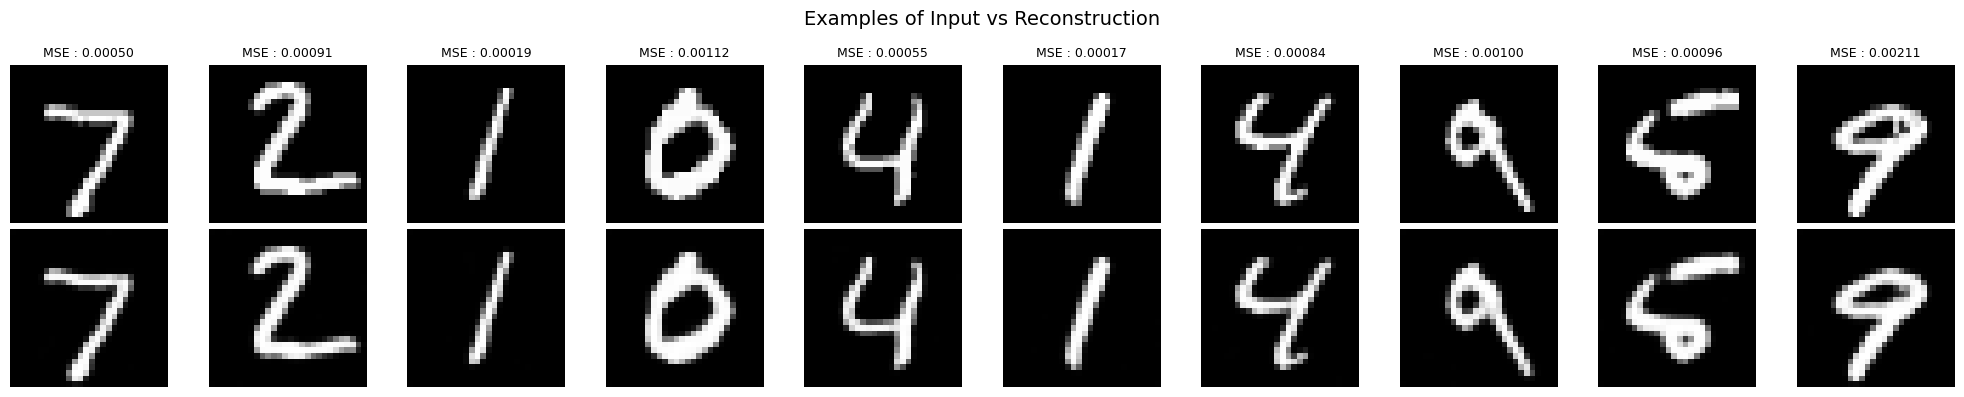

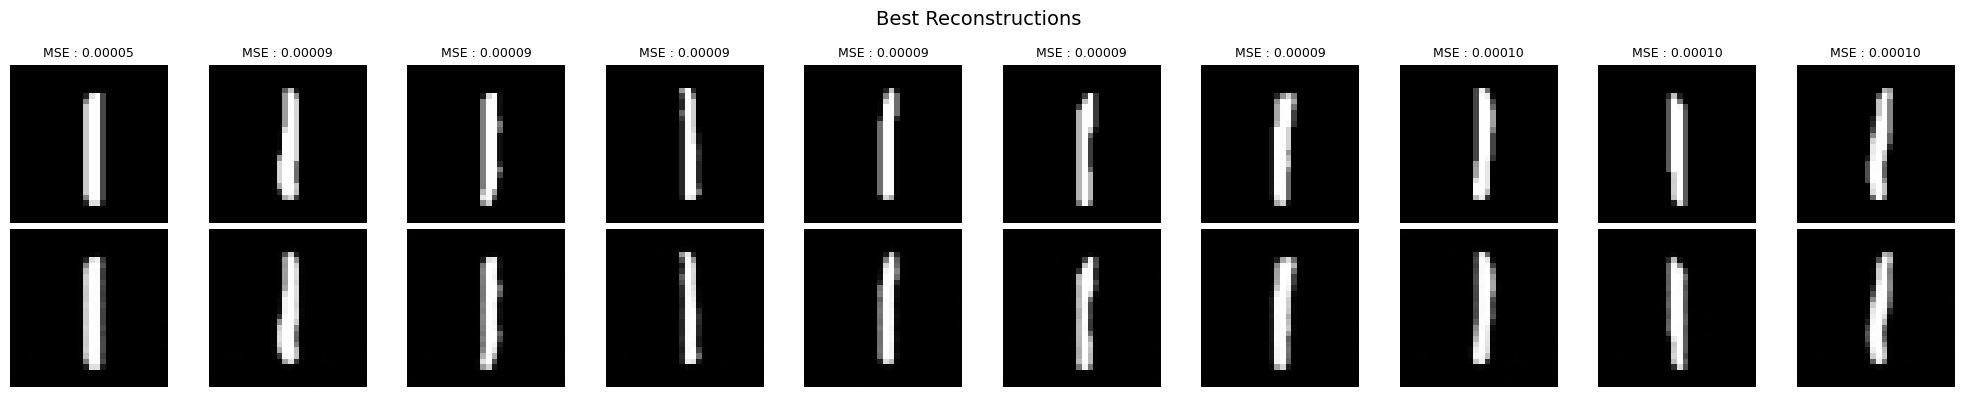

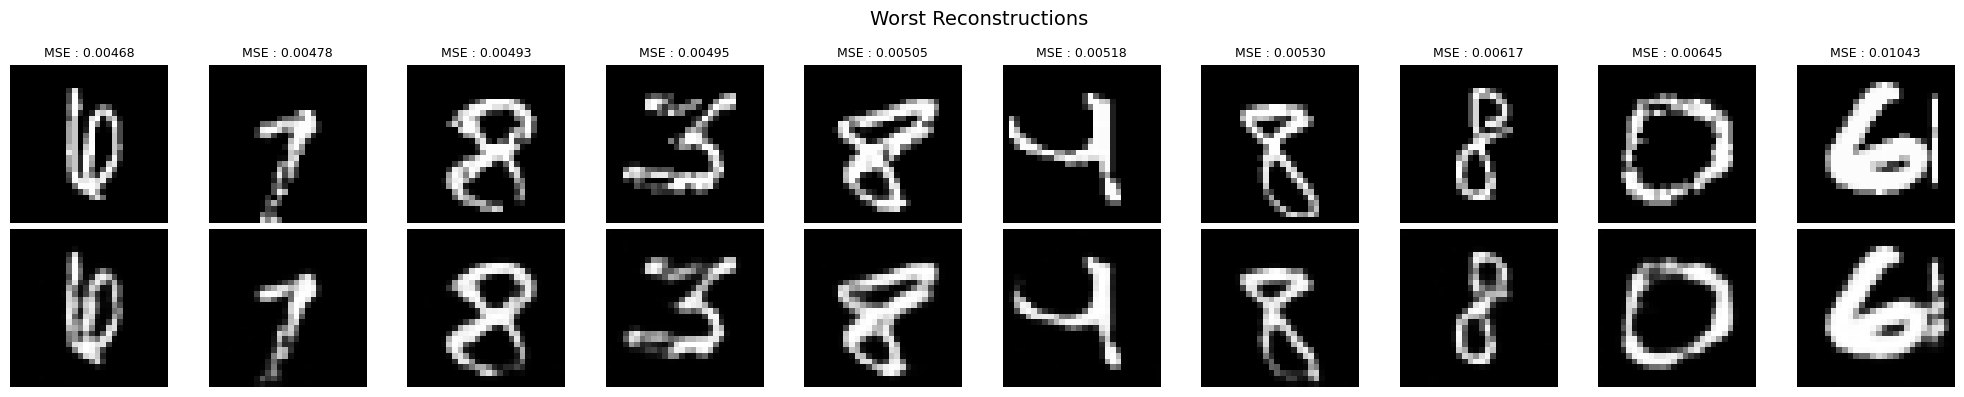

In [114]:
Melchior128_best_state = torch.load("Melchior128_best_state.pt" , map_location = "cpu")
Balthazar147_64_best_state = torch.load("Balthazar147_64_best_state.pt" , map_location = "cpu")


Melchior128_model = Melchior(compressed_dimension = 128)
Melchior128_model.load_state_dict(Melchior128_best_state)
Melchior128_model.eval()


Balthazar147_64_model = Balthazar(channels = 3 , base = 64)
Balthazar147_64_model.load_state_dict(Balthazar147_64_best_state)
Balthazar147_64_model.eval()


Melchior128_test_loss , Melchior128_fit_time = Evaluate_Autoencoder(Melchior128_model , test_dataloader)
print("Melchior128 test MSE:" , round(Melchior128_test_loss , 6))
print("Melchior128 fit time (s):" ,Melchior128_fit_time)
Show_Autoencoder_Reconstructions(Melchior128_model , test_dataloader , next_digit = False , num_examples = 10)

Balthazar147_64_test_loss , Balthazar147_64_fit_time = Evaluate_Autoencoder(Balthazar147_64_model , test_dataloader)
print("Balthazar147_64 test MSE:" , round(Balthazar147_64_test_loss , 6))
print("Balthazar47_64 fit time (s):" , Balthazar147_64_fit_time)
Show_Autoencoder_Reconstructions(Balthazar147_64_model , test_dataloader , next_digit = False , num_examples = 10)

#### - PCA Reconstructions στο Test Set.
Παρακάτω καλούμε τις μεθόδους της κλάσης Eva (που υλοποιεί το PCA Reconstruction). Για δίκαιη σύγκριση επιλέγουμε τόσα components όσα το latent dimension του κάθε AE. Εκτυπώνουμε το loss με βάση το ίδιο κριτήριο (MSE). Και στις δύο περιπτώσεις το variance που διατηρείται είναι περίπου 94%. 
##### Αποτελέσματα: 
Το loss είναι μικρότερη στην περίπτωση των 147 components, οπως περιμέναμε. Με βάση το loss και μόνο δεν υπάρχουν πλεονεκτήματα του MLP AE που να δικαιολογούν την αυξημένη -σε σχέση με το PCA- πολυπλοκόηττά του. Ο Conv AE δίνει καλύτερα αποτελέσματα.

In [115]:
PCA_training_dataloader = DataLoader(training_set , batch_size = 1024 , shuffle = False , num_workers = 2)
PCA_test_dataloader = DataLoader(test_set , batch_size = 1024 , shuffle = False , num_workers = 2)

training_images = Flatten_Images(PCA_training_dataloader)
test_images  = Flatten_Images(PCA_test_dataloader)

start = time.time()
PCA_128 = Eva(n_components = 128).Fit(training_images)
PCA_128_fit_time = np.round(time.time() - start , 2)

start = time.time()
PCA_147 = Eva(n_components = 147).Fit(training_images)
PCA_147_fit_time = np.round(time.time() - start , 2)

print("PCA with 128 components.")
print("Fit time: " , PCA_128_fit_time)
print("Explained variance:" , round(PCA_128.Explained_Variance , 4) , "MSE:" , round(PCA_128.MSE(test_images) , 6))

print("PA with 147 components.")
print("Fit time: " , PCA_147_fit_time)
print("Explained varriance:" , round(PCA_147.Explained_Variance , 4) , "MSE:" , round(PCA_147.MSE(test_images) , 6))

PCA with 128 components.
Fit time:  0.57
Explained variance: 0.9365 MSE: 0.004208
PA with 147 components.
Fit time:  0.5
Explained varriance: 0.947 MSE: 0.00352


#### - Αξιολόγηση του CNN στο Test Set.
Καθώς θα χρησιμοποιήσουμε την ακρίβεια του CNN ως μέτρο ποιότητας ανακατασκευής, ξεκινάμε με την αξιολόγησή του στο αρχικό test set. Ακολουθεί ένα test loop.
##### Αποτελέσματα:
Ακρίβεια 99,31%. Πολύ δυνατή επίδοση. Το Confusion Matrix περιέχει μόνο ελάχιστα σποραδικα missclassifications.

In [116]:
Kasper_best_state = torch.load("Kasper_best_state.pt" , map_location = "cpu")

Kasper_model = Kasper()
Kasper_model.load_state_dict(Kasper_best_state)
Kasper_model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():
    for images , labels in test_dataloader:

        scores = Kasper_model(images)
        predictions = scores.argmax(dim = 1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.append(predictions.cpu())
        all_labels.append(labels.cpu())

test_accuracy = correct / total

all_predictions = torch.cat(all_predictions).numpy()
all_labels = torch.cat(all_labels).numpy()

print("Kasper test accuracy:" , round(test_accuracy , 4))
print("\nConfusion matrix (test):\n" , confusion_matrix(all_labels , all_predictions))
print("\nClassification report (test):\n" , classification_report(all_labels , all_predictions))

Kasper test accuracy: 0.9931

Confusion matrix (test):
 [[ 979    0    0    0    0    0    0    1    0    0]
 [   0 1131    1    1    0    1    1    0    0    0]
 [   1    0 1025    1    0    0    0    5    0    0]
 [   0    0    1 1006    0    3    0    0    0    0]
 [   0    0    0    0  977    0    1    0    1    3]
 [   1    0    0    4    0  886    1    0    0    0]
 [   5    3    1    0    1    1  946    0    1    0]
 [   0    2    5    0    0    0    0 1018    1    2]
 [   1    1    2    0    0    0    0    1  968    1]
 [   0    0    0    1    5    1    1    4    2  995]]

Classification report (test):
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
  

#### - Επίδοση του CNN (Kasper) στον MLP AE (Melchior).
Παρακάτω δοκιμάζουμε το CNN πάνω στα reconstructions του MLP AE. Ουσιαστικά αναλαμβάνουν τον ρόλο του test set. Το test loop παραμένει ίδιο, με μόνη διαφορά ότι τα scores (logits) υπολογίζονται πάνω στις ανακατασκευές. Εξετάζουμε το κατά πόσο το CNN Μπορεί ακόμα να αναγνωρίζει τα ψηφία.
##### ΑΠοτελέσματα:
Έχουμε πτώση ακρίβειας της τάξης του ~0.6% σε σχέση με το αρχικό test set. Ακόμα και το πιο αδύναμο μοντέλο παράγει αξιοπρεπείς ανακατασκευές.

In [117]:
Kasper_best_state = torch.load("Kasper_best_state.pt" , map_location = "cpu")

Kasper_model = Kasper()
Kasper_model.load_state_dict(Kasper_best_state)
Kasper_model.eval()

Melchior128_best_state = torch.load("Melchior128_best_state.pt" , map_location = "cpu")

Melchior128_model = Melchior(compressed_dimension = 128)
Melchior128_model.load_state_dict(Melchior128_best_state)
Melchior128_model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():
    for images , labels in test_dataloader:

        recons = Melchior128_model(images)
        scores = Kasper_model(recons)
        predictions = scores.argmax(dim = 1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.append(predictions.cpu())
        all_labels.append(labels.cpu())

Melchior128_recon_accuracy = correct / total

all_predictions = torch.cat(all_predictions).numpy()
all_labels = torch.cat(all_labels).numpy()

print("Kasper accuracy on Melchior128 reconstructions:" , round(Melchior128_recon_accuracy , 4))
print("\nConfusion matrix:\n" , confusion_matrix(all_labels , all_predictions))
print("\nClassification report:\n" , classification_report(all_labels , all_predictions))


Kasper accuracy on Melchior128 reconstructions: 0.9876

Confusion matrix:
 [[ 977    0    1    0    0    0    1    1    0    0]
 [   0 1129    2    3    0    1    0    0    0    0]
 [   2    1 1018    2    2    0    0    6    1    0]
 [   0    0    1 1002    0    3    0    2    1    1]
 [   0    1    0    0  966    1    4    0    2    8]
 [   2    0    0    6    0  879    2    0    1    2]
 [   5    3    0    0    1    4  945    0    0    0]
 [   0    1    3    1    0    0    0 1021    1    1]
 [   3    1    5    4    2    4    1    2  948    4]
 [   0    0    0    1    6    1    0    9    1  991]]

Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.98      0.99      0.98 

#### - Επίδοση του CNN (Kasper) στον Convolutional AE (Balthazar).
Η ίδια ακριβώς διαδικασία, αλλά στην δυνατότερη εκδοχή του Conv AE.
##### Αποτελέσματα: 
Μηδαμινή πτώση της ακρίβειας. Εξαιρετικές ανακατασκευές.

In [118]:
Kasper_best_state = torch.load("Kasper_best_state.pt" , map_location = "cpu")

Kasper_model = Kasper()
Kasper_model.load_state_dict(Kasper_best_state)
Kasper_model.eval()

Balthazar147_64_best_state = torch.load("Balthazar147_64_best_state.pt" , map_location = "cpu")

Balthazar147_64_model = Balthazar(channels = 3 , base = 64)
Balthazar147_64_model.load_state_dict(Balthazar147_64_best_state)
Balthazar147_64_model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():
    for images , labels in test_dataloader:

        recons = Balthazar147_64_model(images)
        scores = Kasper_model(recons)
        predictions = scores.argmax(dim = 1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.append(predictions.cpu())
        all_labels.append(labels.cpu())

Balthazar147_64_recon_accuracy = correct / total

all_predictions = torch.cat(all_predictions).numpy()
all_labels = torch.cat(all_labels).numpy()

print("Kasper accuracy on Balthazar147_64 reconstructions:" , round(Balthazar147_64_recon_accuracy , 4))
print("\nConfusion matrix:\n" , confusion_matrix(all_labels , all_predictions))
print("\nClassification report:\n" , classification_report(all_labels , all_predictions))


Kasper accuracy on Balthazar147_64 reconstructions: 0.9927

Confusion matrix:
 [[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1133    0    1    0    1    0    0    0    0]
 [   1    1 1024    0    1    0    0    5    0    0]
 [   0    1    2 1004    0    2    0    0    1    0]
 [   0    0    0    0  975    0    1    0    1    5]
 [   1    0    0    4    0  886    1    0    0    0]
 [   3    3    0    0    1    1  950    0    0    0]
 [   0    2    5    1    0    0    0 1018    1    1]
 [   2    0    2    1    0    0    0    2  965    2]
 [   0    0    0    1    6    2    0    4    2  994]]

Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0

#### - Επίδοση του CNN (Kasper) σε PCA (Eva) με 147 Components.
Η ίδια ακριβώς διαδικασία στις ανακατεσκευές του PCA. 
##### Αποτελέσματα:
Πτώση επίδοσης της τάξης του 0.15%. Σχεδόν αμελητέα. Πολύ καλές ανακασκευές.

In [119]:
Kasper_best_state = torch.load("Kasper_best_state.pt" , map_location = "cpu")

Kasper_model = Kasper()
Kasper_model.load_state_dict(Kasper_best_state)
Kasper_model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():
    for images , labels in test_dataloader:

        x = images.view(images.size(0) , -1).numpy()
        xhat = PCA_147.Reconstruct(x)
        xhat = np.clip(xhat , 0.0 , 1.0)

        recons = torch.from_numpy(xhat).float().view(images.size(0) , 1 , 28 , 28)

        scores = Kasper_model(recons)
        predictions = scores.argmax(dim = 1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.append(predictions.cpu())
        all_labels.append(labels.cpu())

PCA_147_recon_accuracy = correct / total

all_predictions = torch.cat(all_predictions).numpy()
all_labels = torch.cat(all_labels).numpy()

print("Kasper accuracy on PCA_147 reconstructions:" , round(PCA_147_recon_accuracy , 4))
print("\nConfusion matrix:\n" , confusion_matrix(all_labels , all_predictions))
print("\nClassification report:\n" , classification_report(all_labels , all_predictions))

Kasper accuracy on PCA_147 reconstructions: 0.9916

Confusion matrix:
 [[ 979    0    0    0    0    0    0    1    0    0]
 [   0 1130    1    1    0    2    1    0    0    0]
 [   2    0 1020    1    2    0    0    7    0    0]
 [   0    1    1 1004    0    3    0    0    1    0]
 [   0    0    0    0  971    0    1    0    1    9]
 [   1    0    0    4    0  885    1    0    0    1]
 [   5    3    1    0    1    1  947    0    0    0]
 [   0    3    3    0    0    0    0 1021    1    0]
 [   1    1    2    0    0    1    1    1  965    2]
 [   0    0    0    0    4    3    1    5    2  994]]

Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99     

### 9. Ανακατασκευή Επόμενου Ψηφίου.
#### - Κλάση Next Digit Dataset.
Η ιδέα πίσω από την λειτουργία ανακατασκεής επόμενου ψηφίου είναι η εξής: Εκπαιδεύουμε όπως ακριβώς κάναμε πριν. Δεν υπάρχει αλλαγή στην αρχιτεκτονική του μοντέλου. Εισάγουμε ωστόσο σαν target εικόνες από την επόμενη ακριβώς κλάση. Δηλαδή υπολογίζουμε το MSE loss με βάση την εικόνα της κλάσης "τωρινό ψηφίο + 1". Δημιουργούμε ουσιαστικά ένα επιπλέον dataset με βάση το αρχικό. 
##### To Pipeline:
1. Δημιουργούμε δέκα λίστες από θέσεις των στοιχείων της κάθε κλάσης.
2. Για κάθε στοιχείο της κάθε κλάσης, το αντιστοιχούμε με ένα στοιχείο της επόμενης. Η διαδικασία γίνεται ντετερμινιστικά, με βάση την σειρά στην οποία εμφανίζονται στο αρχικό dataset. Το 9 αντιστοιχίζεται με 0. Εάν η κλάση d + 1 δεν έχει αρκετά στοιχεία (το όποιο όπως ειδαμε νωρίτερα στην κατανομή των κλάσεων συμβαίνει), αντιστοιχούμε πάλι από την αρχή της λίστας. Είναι επίσης πιθανό κάποια στοιχεία να μην αναλάβουν ποτέ ρόλο target.
3. Επιστρέφουμε αρχικλη εικόνα, εικόνα επόμενου ψηφίου και label αρχικής εικόνας.

Η συγκεκριμένη αρχιτεκτονική είναι μία από τις διάφορες που θα μπορούσαν να υλοποιηθούν. Η αντιστοίχιση 9 με 0 είναι desing choice. Όπως επίσης και το detterministic assignment. Θα μπορούσε να γίνεται τυχαία ανάθεση. 

In [45]:
class Next_Digit_Dataset(torch.utils.data.Dataset):

    def __init__(self , base_dataset , indices):

        ########################## Setup ##########################

        #Store base dataset and subset indices.
        self.base_dataset = base_dataset
        self.indices = np.array(indices)

        #Extract labels for the selected indices.
        labels = base_dataset.targets[self.indices].cpu().numpy()

        #Group dataset indices by class (digit -> list of indices).
        self.by_class = {d : self.indices[labels == d].tolist() for d in range(10)}

        ########################## Build Pairs ##########################

        #Initialize mapping from source index to next digit tagret index.
        self.pair = {}

        #For each digit , pair each sample with a sample from digit + 1 modulo 10.
        #ModuLo 10 sends pairs 9 with 0 as the next digit, just a design choice.
        for d in range(10):
            #Collect source indices from class d.
            source = self.by_class[d]
            #Collect target indices from next class.
            target = self.by_class[(d + 1) % 10]

            #Create pairing.
            #If one class has fewer samples , cycle through targets using modulo.
            for k , source_index in enumerate(source):
                self.pair[source_index] = target[k % len(target)]

    def __len__(self):
        #Return number of samples in the subset.
        return len(self.indices)

    def __getitem__(self , i):

        ########################## Fetch Digit - Next Digit Pairs ##########################

        #Select source dataset index from subset loaction i.
        source_index = int(self.indices[i])
        #Find paired target dataset index (next digit class).
        target_index = int(self.pair[source_index])

        #Load source image and label.
        image , label = self.base_dataset[source_index]
        #Load target image (label is not needed here).
        target_image , _ = self.base_dataset[target_index]

        #Return input image , next-digit target image , and original label for reference.
        return image , target_image , label


#### - Δημιουργία Next Digit Dataset.
Για να λειτουργήσει το Training loop με next_digit = True, το dataset πρέπει να είναι της μορφής (image , target_image , label). Αυτό ακριβώς επιστρέφεται από το ακόλουθο cell, όταν καλείται η κλάση Next_Digit_Dataset. Προσοχή, το validation_dataset πρέπει να είναι ορισμένο εκτός του training loop, γι αυτό το κάνουμε overwrite. 

In [48]:
next_digit_training_set = Next_Digit_Dataset(training_set_full , training_indices)
next_digit_validation_set = Next_Digit_Dataset(training_set_full , validation_indices)

next_digit_training_dataloader = DataLoader(next_digit_training_set , batch_size = 128 , shuffle = True , num_workers = 0)
validation_dataloader = DataLoader(next_digit_validation_set , batch_size = 256 , shuffle = False , num_workers = 0)

#### - Eκπαίδευση Convolutional AE στην Δημιουργία Επόμενου Ψηφίου.
Επιλέξαμε τον πιο ικανό AE ως αρχή στα πειράματα μας. Καθώς τον loss είναι δεκάδες φορές μεγαλύτερο, αυξήσαμε το μέγεθος του latent dimension στα επόμενα πειράματα, χωρίς όμως κάποιο κέρδος.
##### Setups:
1. channels = 3 , base = 64
2. channels = 4 , base = 96
3. channels = 8 , base = 96
4. channels = 8 , base = 128
##### Αποτελέσματα: 
Σχεδόν ίδιο loss και στα τέσσερα πειράματα. Με δεδομένο πως ο χρόνος εκπαίδευσης αυξάνεται καθως μαγαλώνει το μοντέλο, δεν αξίζει η διεύρυνσή του. Τα reconstructions είναι πλέον αισθητά πιο θολά, χωρίς αυτό να σημείνει πως θα επηρρεάσει την επίδοση του ΝΝ απαραίτητα.. 

In [52]:
Balthazar147_64_ND = Balthazar(channels = 3 , base = 64)

Balthazar147_64_ND , Balthazar147_64_ND_best_state , Balthazar147_64_ND_results = Train_Autoencoder(
    model = Balthazar147_64_ND ,
    lr = 1e-3 ,
    num_epochs = 20 ,
    training_dataloader = next_digit_training_dataloader ,
    next_digit = True
)

torch.save(Balthazar147_64_ND_results , "Balthazar147_64_ND_results.pt")
torch.save(Balthazar147_64_ND_best_state , "Balthazar147_64_ND_best_state.pt")

print(Balthazar147_64_ND_results["learning_rates"])

Epoch 01 | Train (during updates): 0.064385 | Train-eval: 0.058118 | Val: 0.058034
Epoch 02 | Train (during updates): 0.057501 | Train-eval: 0.056723 | Val: 0.056727
Epoch 03 | Train (during updates): 0.056548 | Train-eval: 0.056223 | Val: 0.056330
Epoch 04 | Train (during updates): 0.056111 | Train-eval: 0.055838 | Val: 0.056001
Epoch 05 | Train (during updates): 0.055848 | Train-eval: 0.055499 | Val: 0.055724
Epoch 06 | Train (during updates): 0.055646 | Train-eval: 0.055363 | Val: 0.055652
Epoch 07 | Train (during updates): 0.055184 | Train-eval: 0.055012 | Val: 0.055404
Epoch 08 | Train (during updates): 0.055085 | Train-eval: 0.054911 | Val: 0.055373
Epoch 09 | Train (during updates): 0.054814 | Train-eval: 0.054615 | Val: 0.055185
Epoch 10 | Train (during updates): 0.054745 | Train-eval: 0.054554 | Val: 0.055219
Epoch 11 | Train (during updates): 0.054571 | Train-eval: 0.054428 | Val: 0.055165
Epoch 12 | Train (during updates): 0.054516 | Train-eval: 0.054393 | Val: 0.055190
Epoc

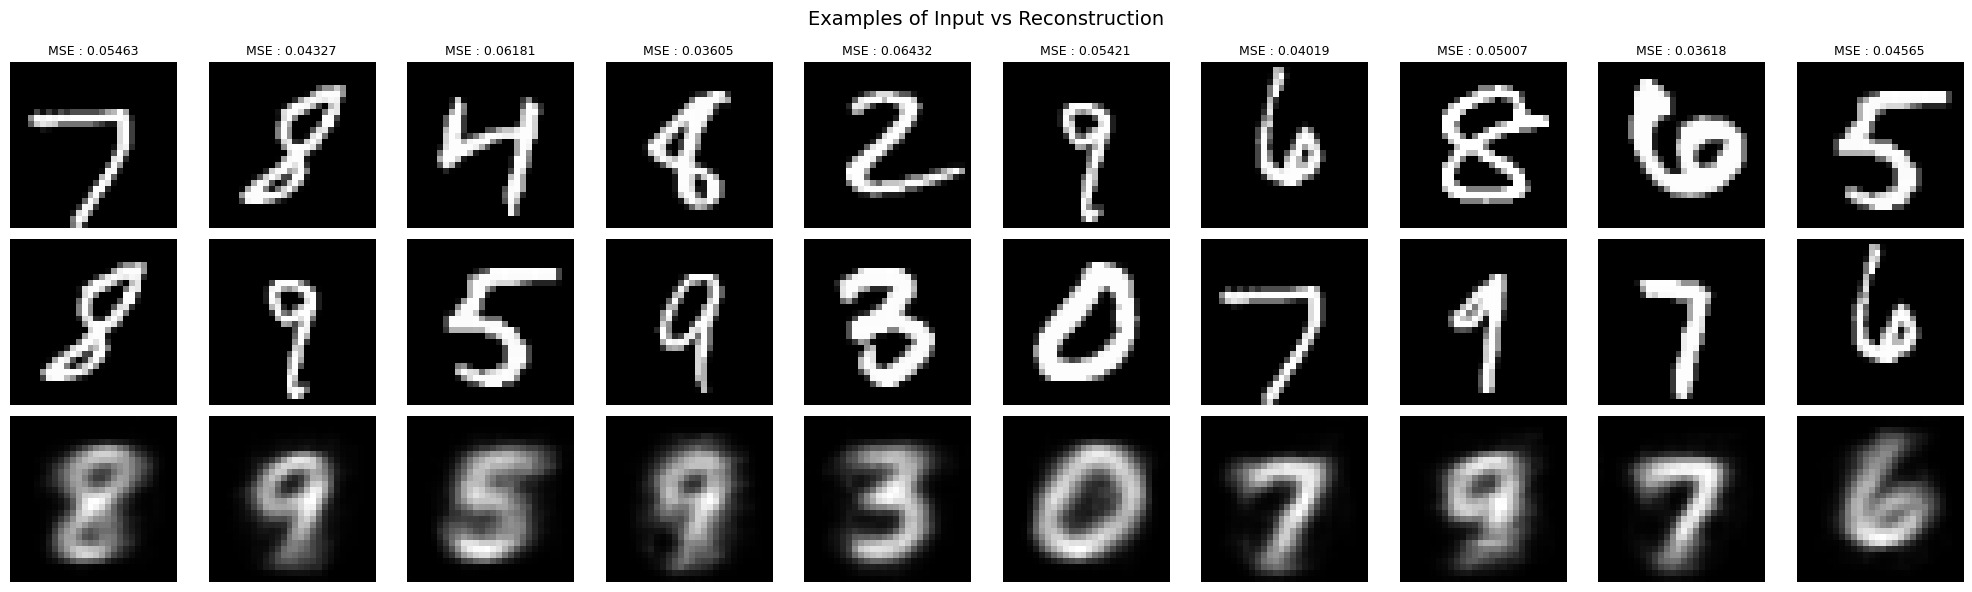

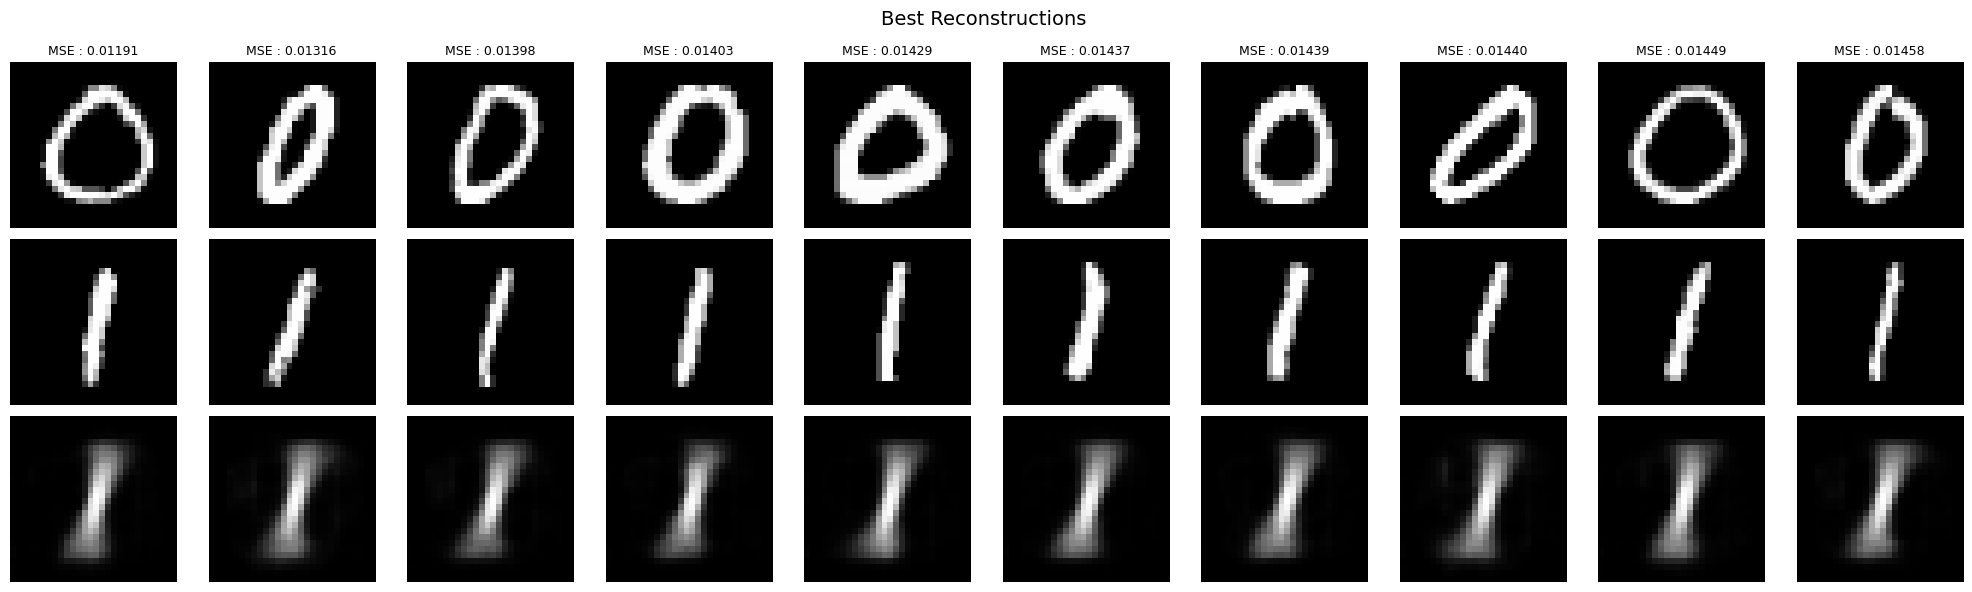

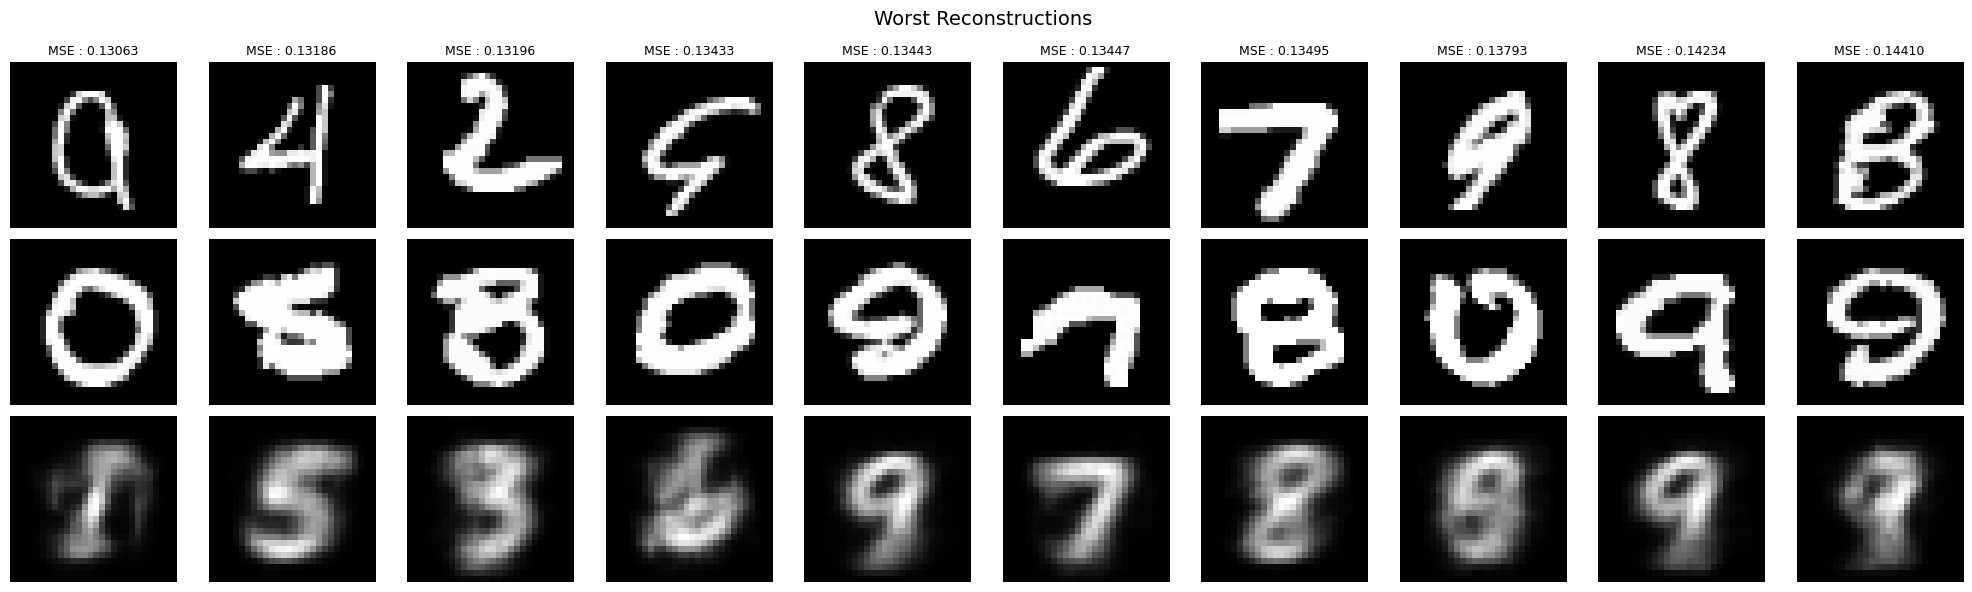

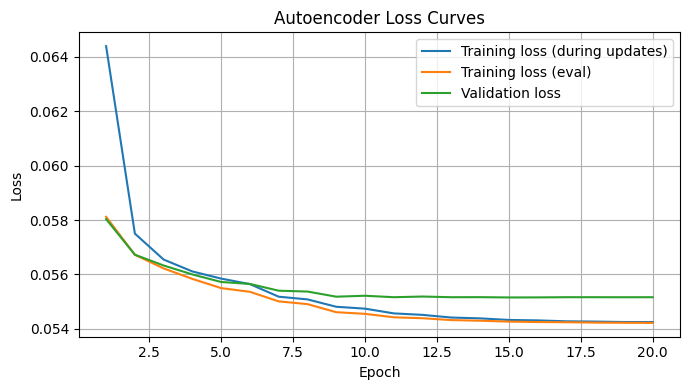

In [58]:
Show_Autoencoder_Reconstructions(Balthazar147_64_ND , validation_dataloader , next_digit = True , num_examples = 10)

Balthazar147_64_ND_results = torch.load("Balthazar147_64_ND_results.pt" , map_location = "cpu")
Plot_Autoencoder_Curves(Balthazar147_64_ND_results)

In [48]:
Balthazar196_96_ND = Balthazar(channels = 4 , base = 96)

Balthazar196_96_ND , Balthazar196_96_ND_best_state , Balthazar196_96_ND_results = Train_Autoencoder(
    model = Balthazar196_96_ND ,
    lr = 1e-3 ,
    num_epochs = 20 ,
    training_dataloader = next_digit_training_dataloader ,
    next_digit = True
)

torch.save(Balthazar196_96_ND_results , "Balthazar196_96_ND_results.pt")
torch.save(Balthazar196_96_ND_best_state , "Balthazar196_96_ND_best_state.pt")

print(Balthazar196_96_ND_results["learning_rates"])

Epoch 01 | Train (during updates): 0.062930 | Train-eval: 0.057260 | Val: 0.057285
Epoch 02 | Train (during updates): 0.056715 | Train-eval: 0.056294 | Val: 0.056387
Epoch 03 | Train (during updates): 0.055959 | Train-eval: 0.055525 | Val: 0.055730
Epoch 04 | Train (during updates): 0.055569 | Train-eval: 0.055244 | Val: 0.055494
Epoch 05 | Train (during updates): 0.055320 | Train-eval: 0.055020 | Val: 0.055365
Epoch 06 | Train (during updates): 0.055138 | Train-eval: 0.054811 | Val: 0.055226
Epoch 07 | Train (during updates): 0.054977 | Train-eval: 0.054778 | Val: 0.055293
Epoch 08 | Train (during updates): 0.054552 | Train-eval: 0.054277 | Val: 0.055027
Epoch 09 | Train (during updates): 0.054441 | Train-eval: 0.054268 | Val: 0.055164
Epoch 10 | Train (during updates): 0.054144 | Train-eval: 0.053907 | Val: 0.055037
Epoch 11 | Train (during updates): 0.054035 | Train-eval: 0.053784 | Val: 0.055089
Epoch 12 | Train (during updates): 0.053792 | Train-eval: 0.053606 | Val: 0.055043
Epoc

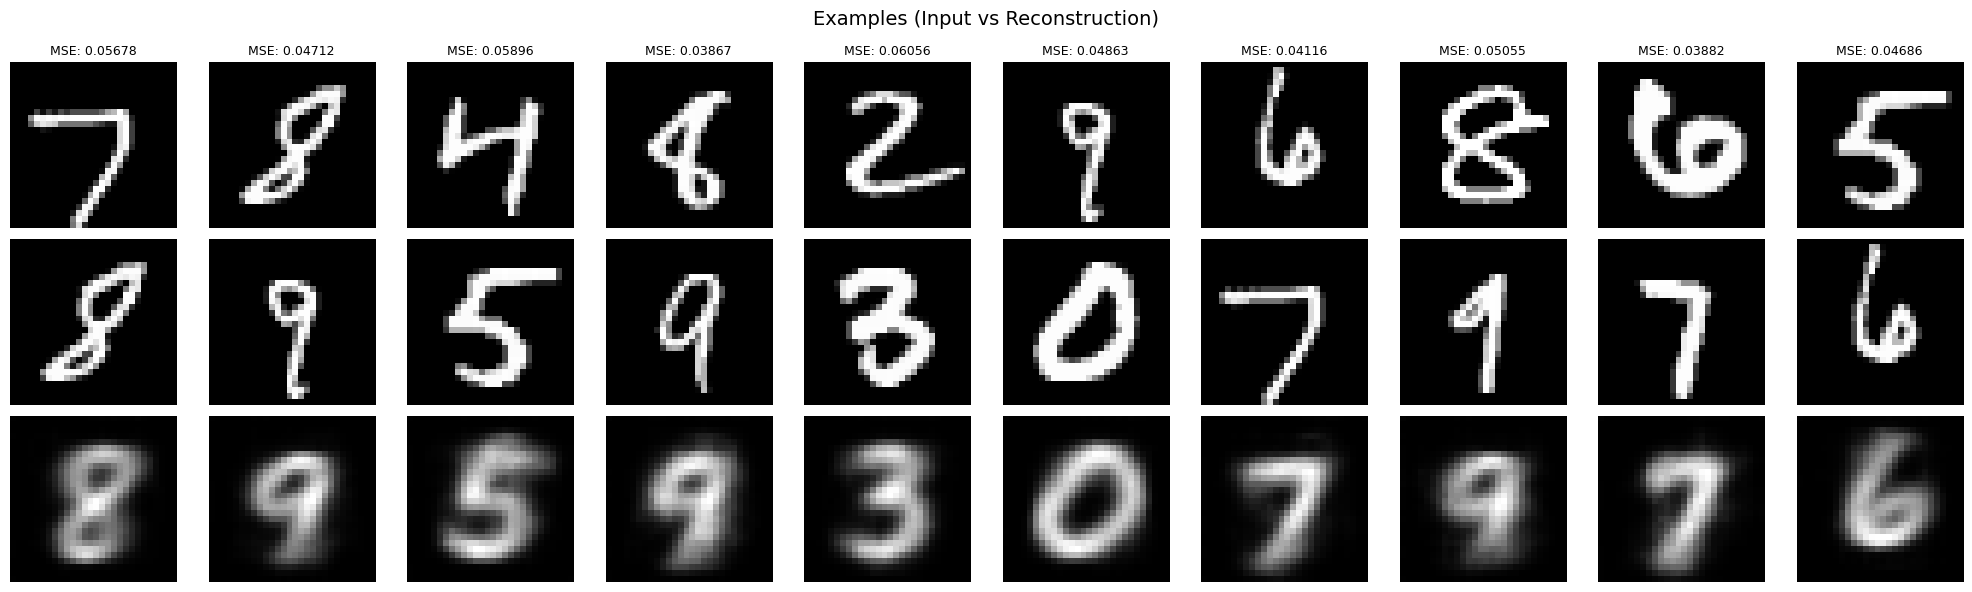

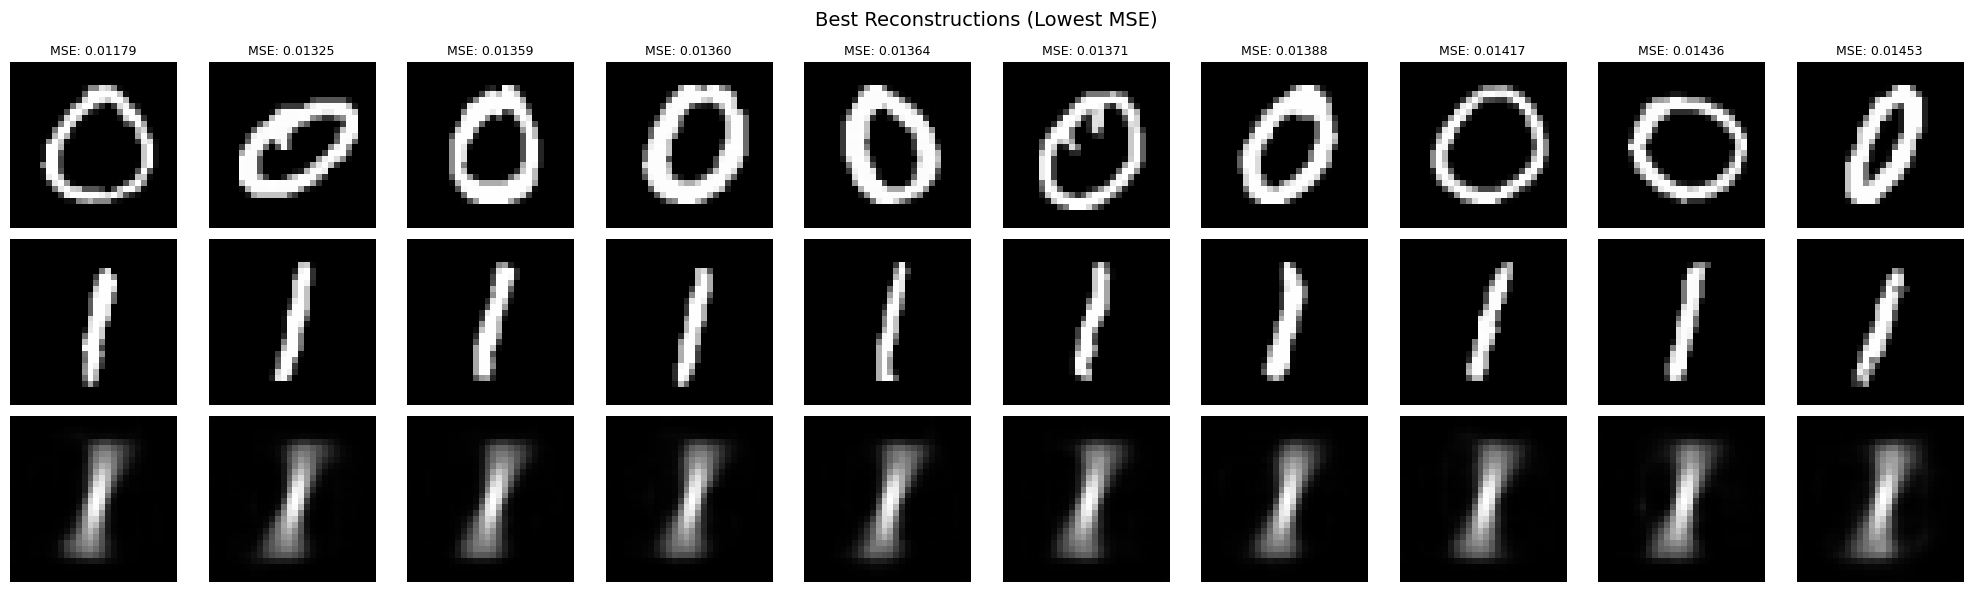

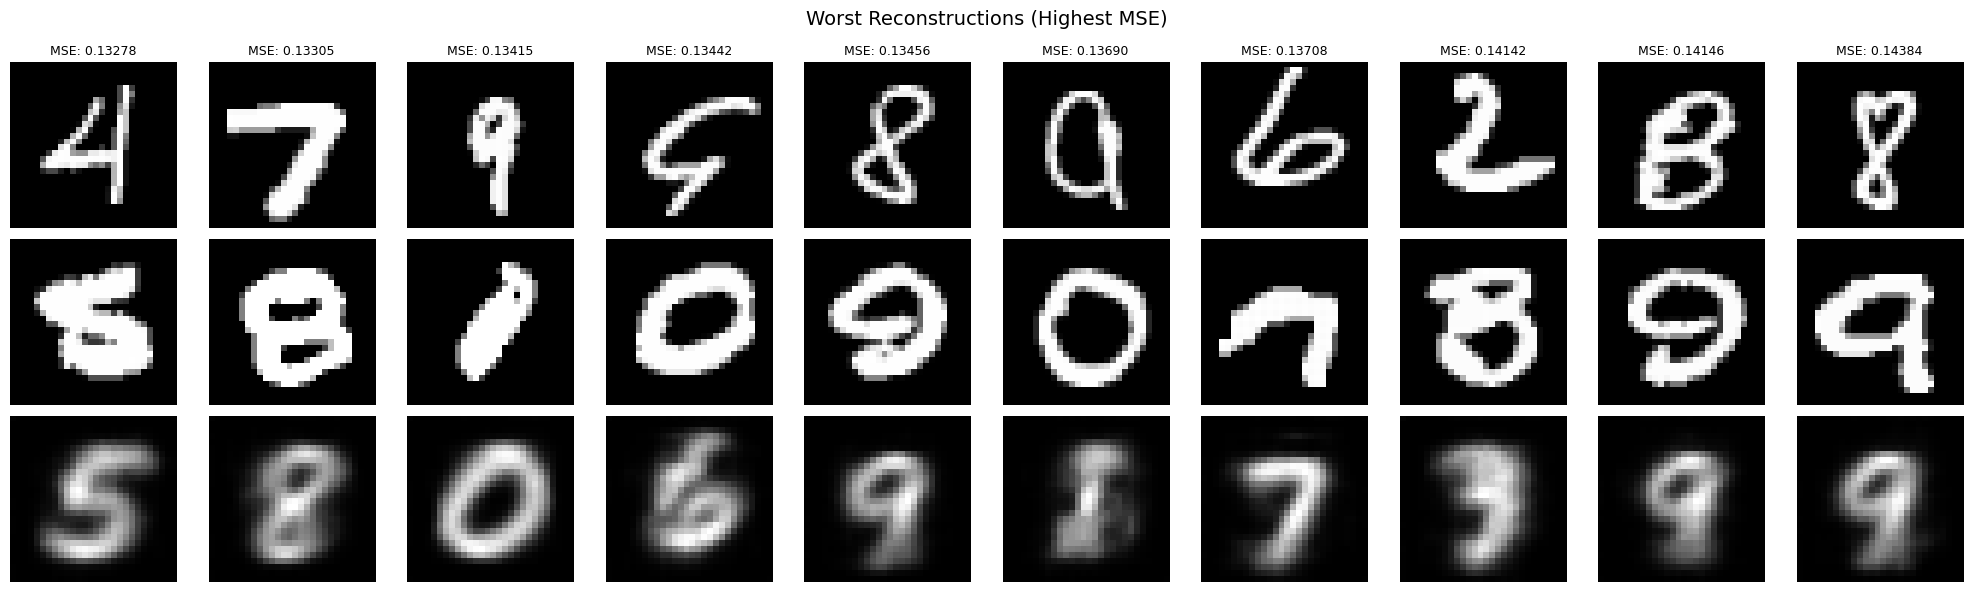

In [49]:
Show_Autoencoder_Reconstructions(Balthazar196_96_ND , validation_dataloader , next_digit = True , num_examples = 10)

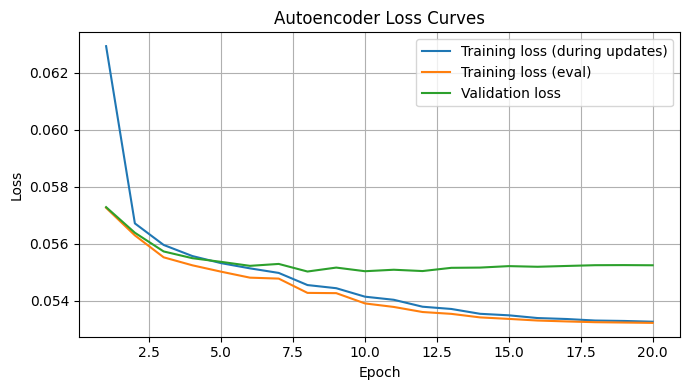

In [59]:
Balthazar196_96_ND_results = torch.load("Balthazar196_96_ND_results.pt" , map_location = "cpu")
Plot_Autoencoder_Curves(Balthazar196_96_ND_results)

In [50]:
Balthazar392_96_ND = Balthazar(channels = 8 , base = 96)

Balthazar392_96_ND , Balthazar392_96_ND_best_state , Balthazar392_96_ND_results = Train_Autoencoder(
    model = Balthazar392_96_ND ,
    lr = 1e-3 ,
    num_epochs = 20 ,
    training_dataloader = next_digit_training_dataloader ,
    next_digit = True
)

torch.save(Balthazar392_96_ND_results , "Balthazar392_96_ND_results.pt")
torch.save(Balthazar392_96_ND_best_state , "Balthazar392_96_ND_best_state.pt")

print(Balthazar392_96_ND_results["learning_rates"])

Epoch 01 | Train (during updates): 0.061744 | Train-eval: 0.057060 | Val: 0.057044
Epoch 02 | Train (during updates): 0.056392 | Train-eval: 0.055779 | Val: 0.055919
Epoch 03 | Train (during updates): 0.055687 | Train-eval: 0.055357 | Val: 0.055520
Epoch 04 | Train (during updates): 0.055325 | Train-eval: 0.055064 | Val: 0.055324
Epoch 05 | Train (during updates): 0.055095 | Train-eval: 0.054736 | Val: 0.055109
Epoch 06 | Train (during updates): 0.054898 | Train-eval: 0.054610 | Val: 0.055022
Epoch 07 | Train (during updates): 0.054467 | Train-eval: 0.054222 | Val: 0.054855
Epoch 08 | Train (during updates): 0.054348 | Train-eval: 0.054114 | Val: 0.054865
Epoch 09 | Train (during updates): 0.054024 | Train-eval: 0.053762 | Val: 0.054837
Epoch 10 | Train (during updates): 0.053912 | Train-eval: 0.053673 | Val: 0.054907
Epoch 11 | Train (during updates): 0.053655 | Train-eval: 0.053447 | Val: 0.054932
Epoch 12 | Train (during updates): 0.053558 | Train-eval: 0.053358 | Val: 0.054974
Epoc

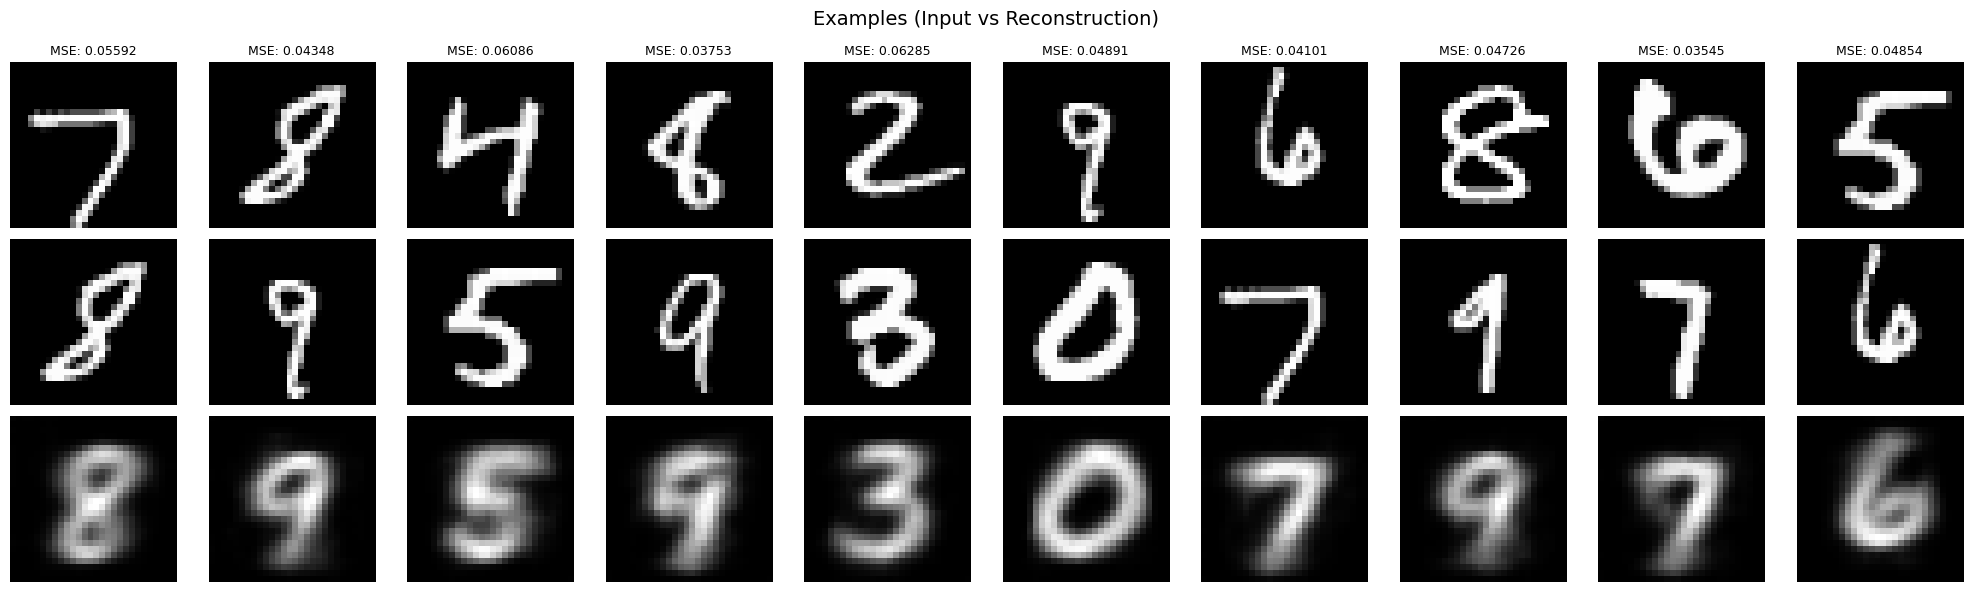

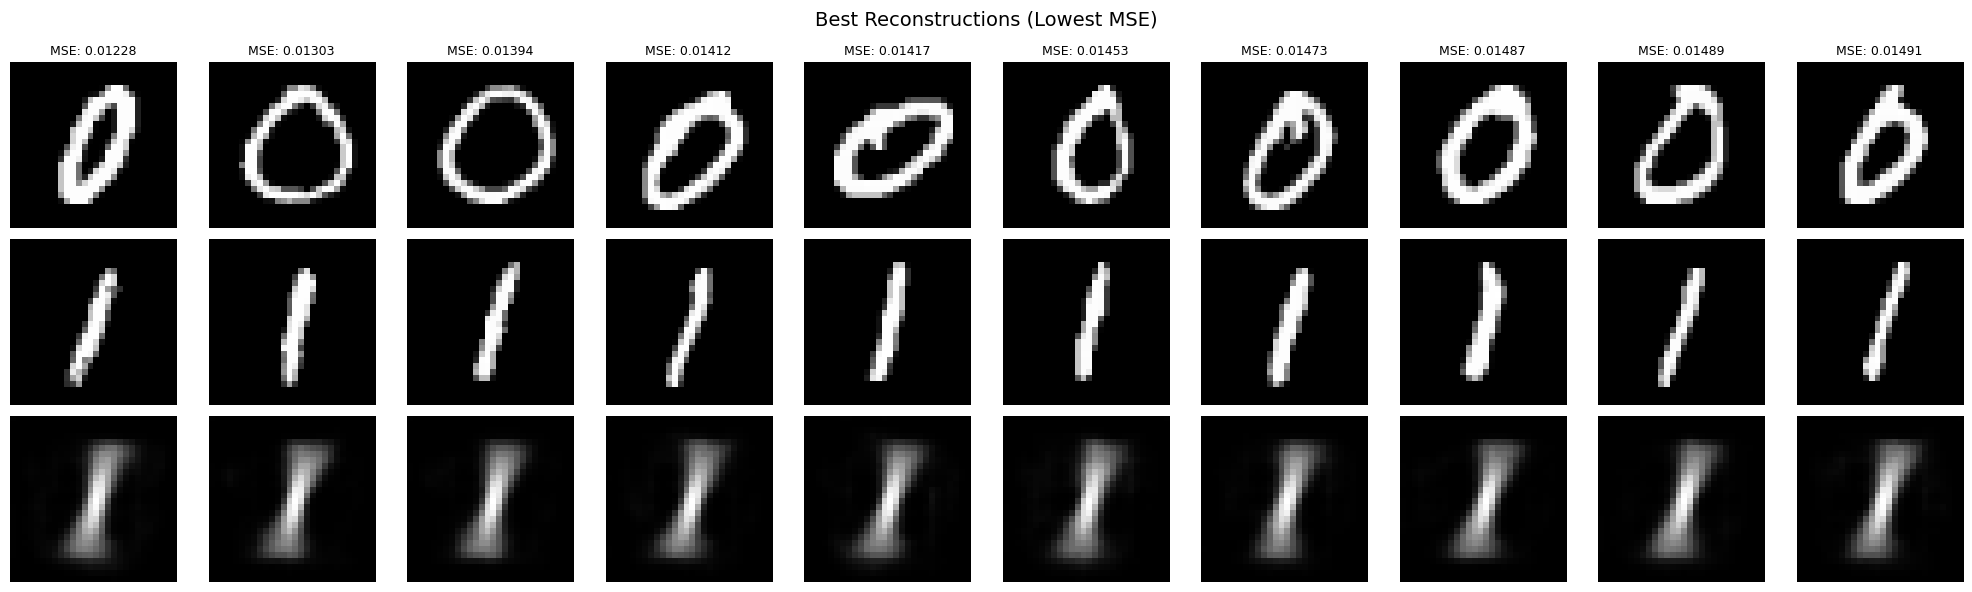

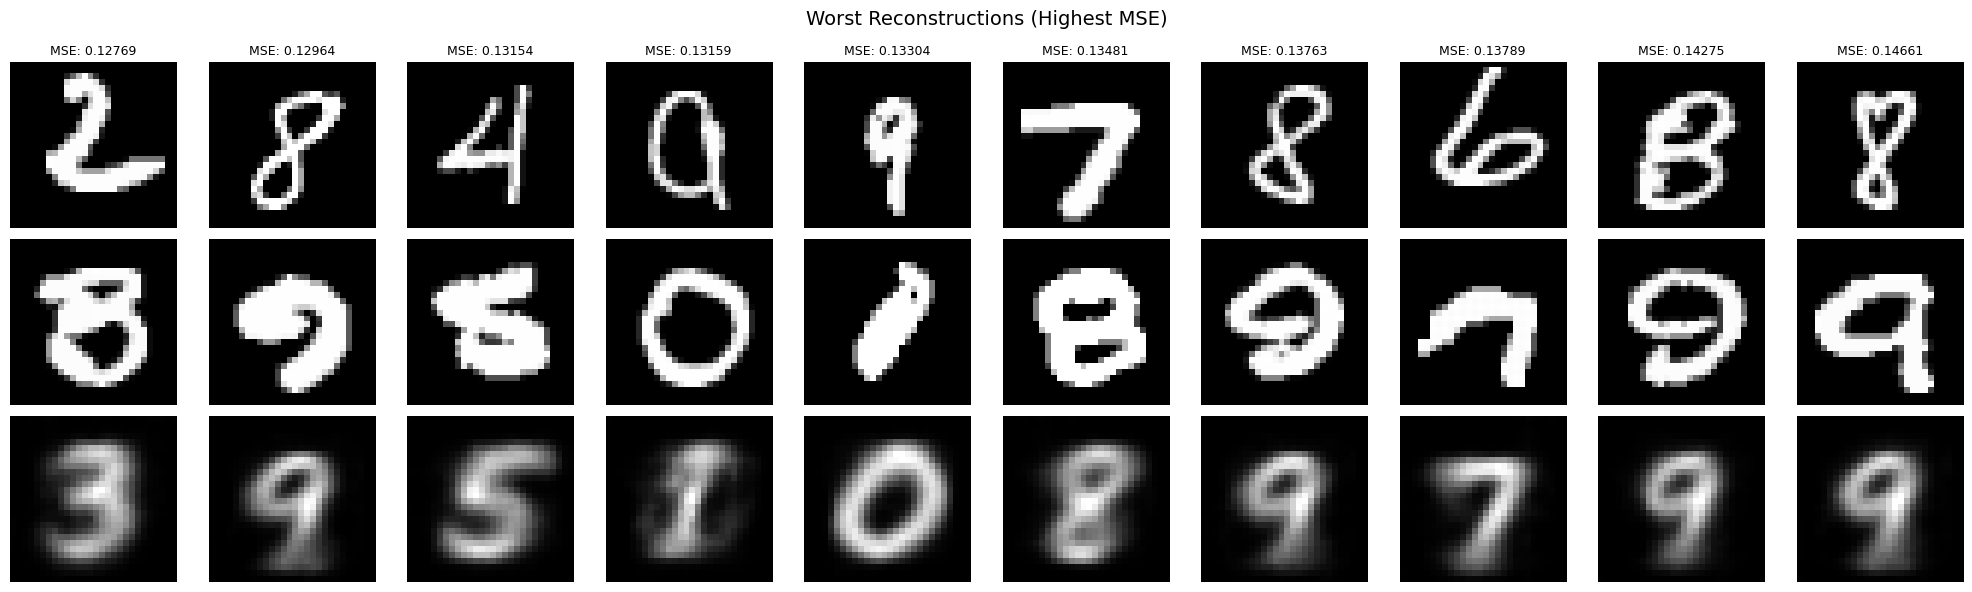

In [51]:

Show_Autoencoder_Reconstructions(Balthazar392_96_ND , validation_dataloader , next_digit = True , num_examples = 10)

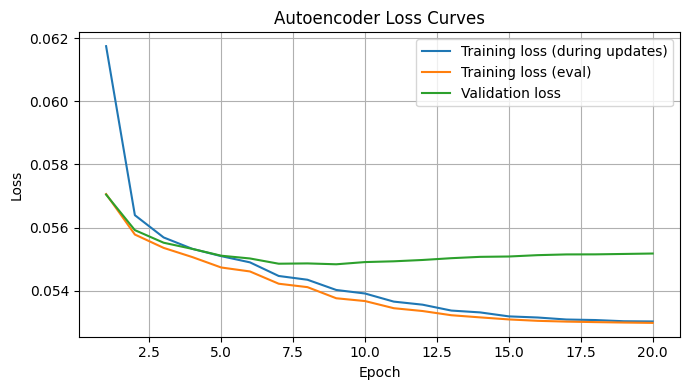

In [62]:
Balthazar392_96_ND_results = torch.load("Balthazar392_96_ND_results.pt" , map_location = "cpu")
Plot_Autoencoder_Curves(Balthazar392_96_ND_results)

In [52]:
Balthazar392_128_ND = Balthazar(channels = 8 , base = 128)

Balthazar392_128_ND , Balthazar392_128_ND_best_state , Balthazar392_128_ND_results = Train_Autoencoder(
    model = Balthazar392_128_ND ,
    lr = 1e-3 ,
    num_epochs = 20 ,
    training_dataloader = next_digit_training_dataloader ,
    next_digit = True
)

torch.save(Balthazar392_128_ND_results , "Balthazar392_128_ND_results.pt")
torch.save(Balthazar392_128_ND_best_state , "Balthazar392_128_ND_best_state.pt")

print(Balthazar392_128_ND_results["learning_rates"])

Epoch 01 | Train (during updates): 0.062378 | Train-eval: 0.056968 | Val: 0.057013
Epoch 02 | Train (during updates): 0.056462 | Train-eval: 0.056294 | Val: 0.056362
Epoch 03 | Train (during updates): 0.055689 | Train-eval: 0.055224 | Val: 0.055401
Epoch 04 | Train (during updates): 0.055311 | Train-eval: 0.054945 | Val: 0.055235
Epoch 05 | Train (during updates): 0.055038 | Train-eval: 0.054699 | Val: 0.055089
Epoch 06 | Train (during updates): 0.054850 | Train-eval: 0.054558 | Val: 0.055129
Epoch 07 | Train (during updates): 0.054406 | Train-eval: 0.054134 | Val: 0.054885
Epoch 08 | Train (during updates): 0.054261 | Train-eval: 0.053986 | Val: 0.054880
Epoch 09 | Train (during updates): 0.053906 | Train-eval: 0.053609 | Val: 0.054900
Epoch 10 | Train (during updates): 0.053770 | Train-eval: 0.053525 | Val: 0.054999
Epoch 11 | Train (during updates): 0.053443 | Train-eval: 0.053172 | Val: 0.055024
Epoch 12 | Train (during updates): 0.053301 | Train-eval: 0.053046 | Val: 0.055102
Epoc

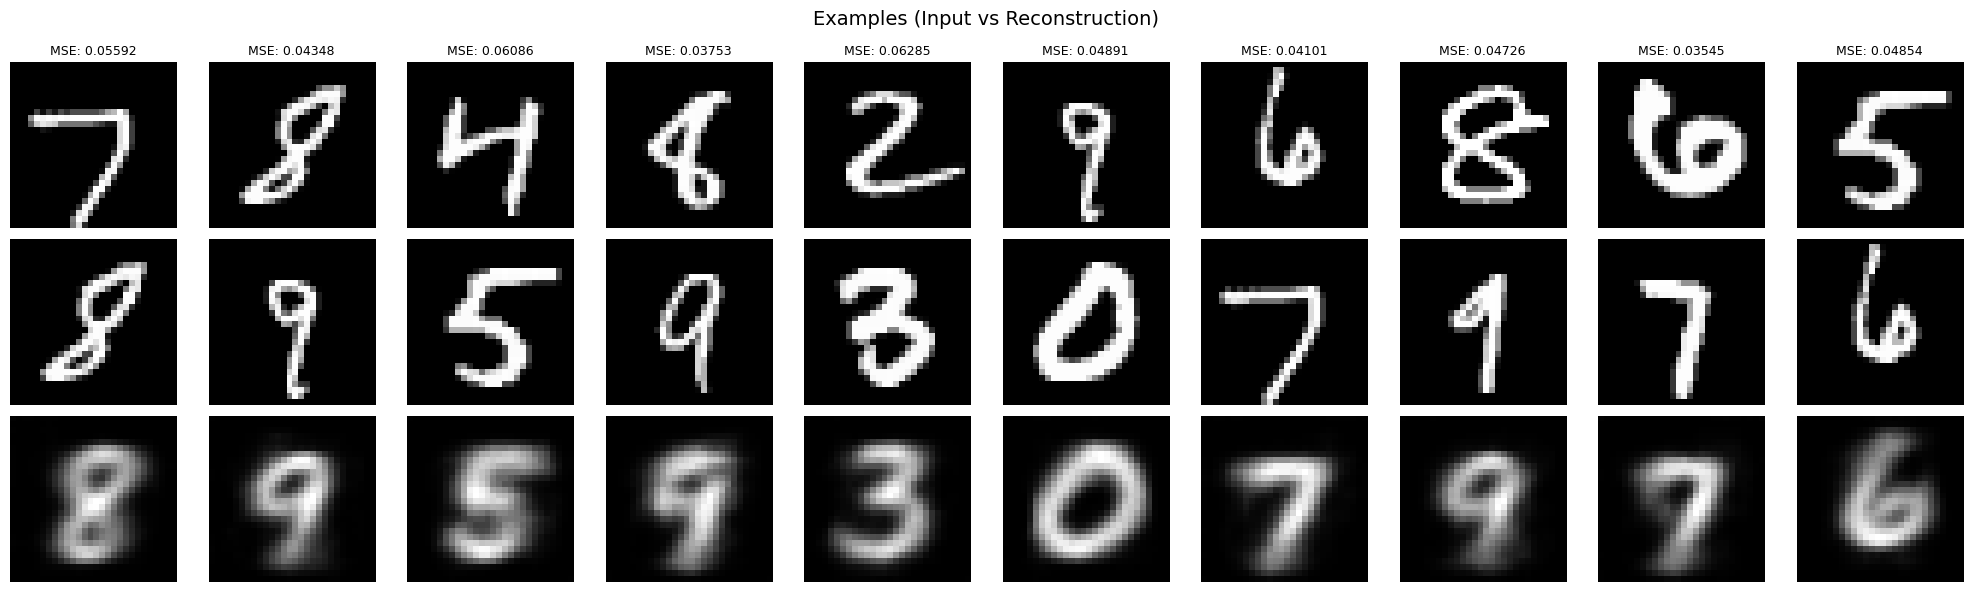

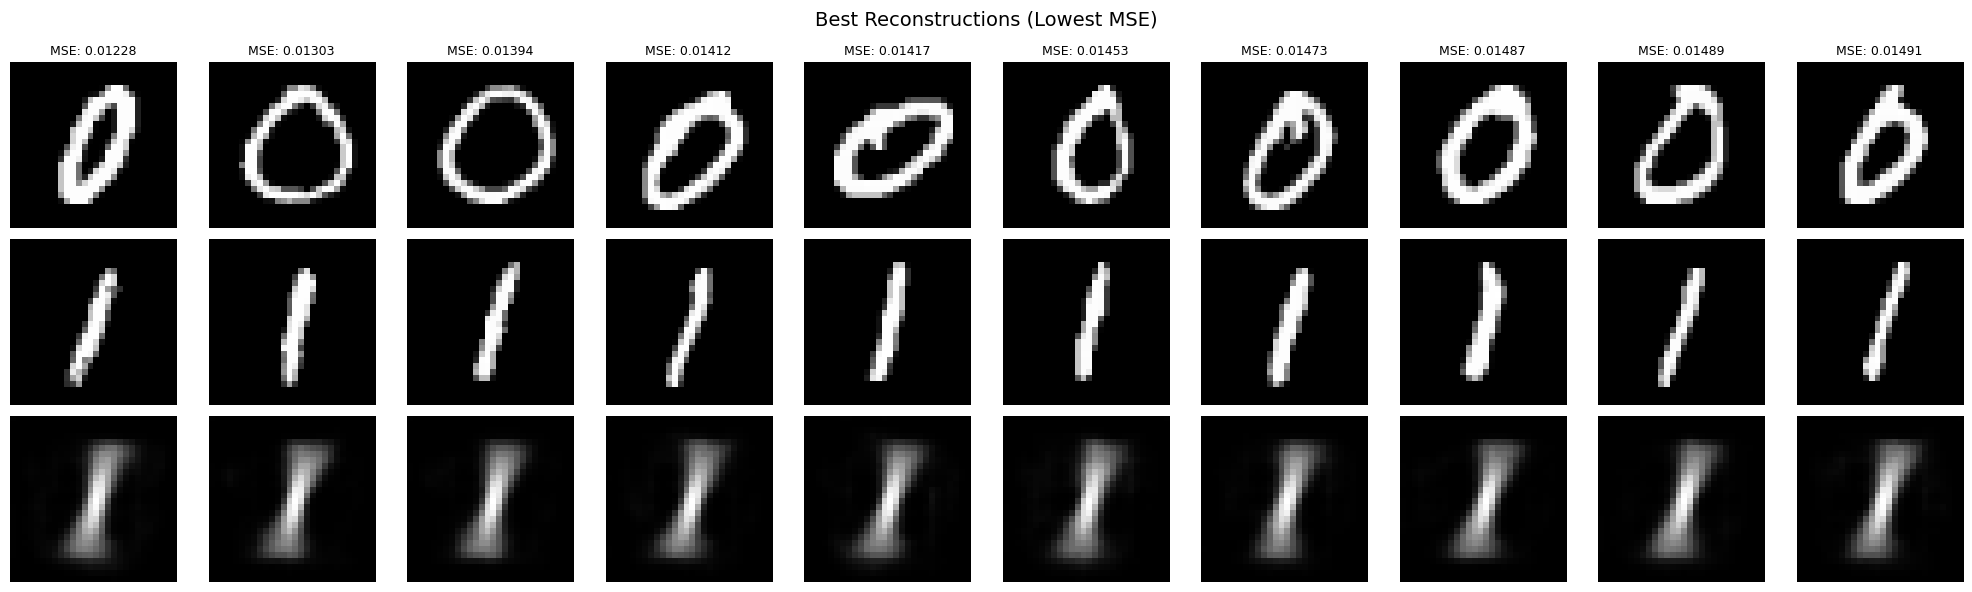

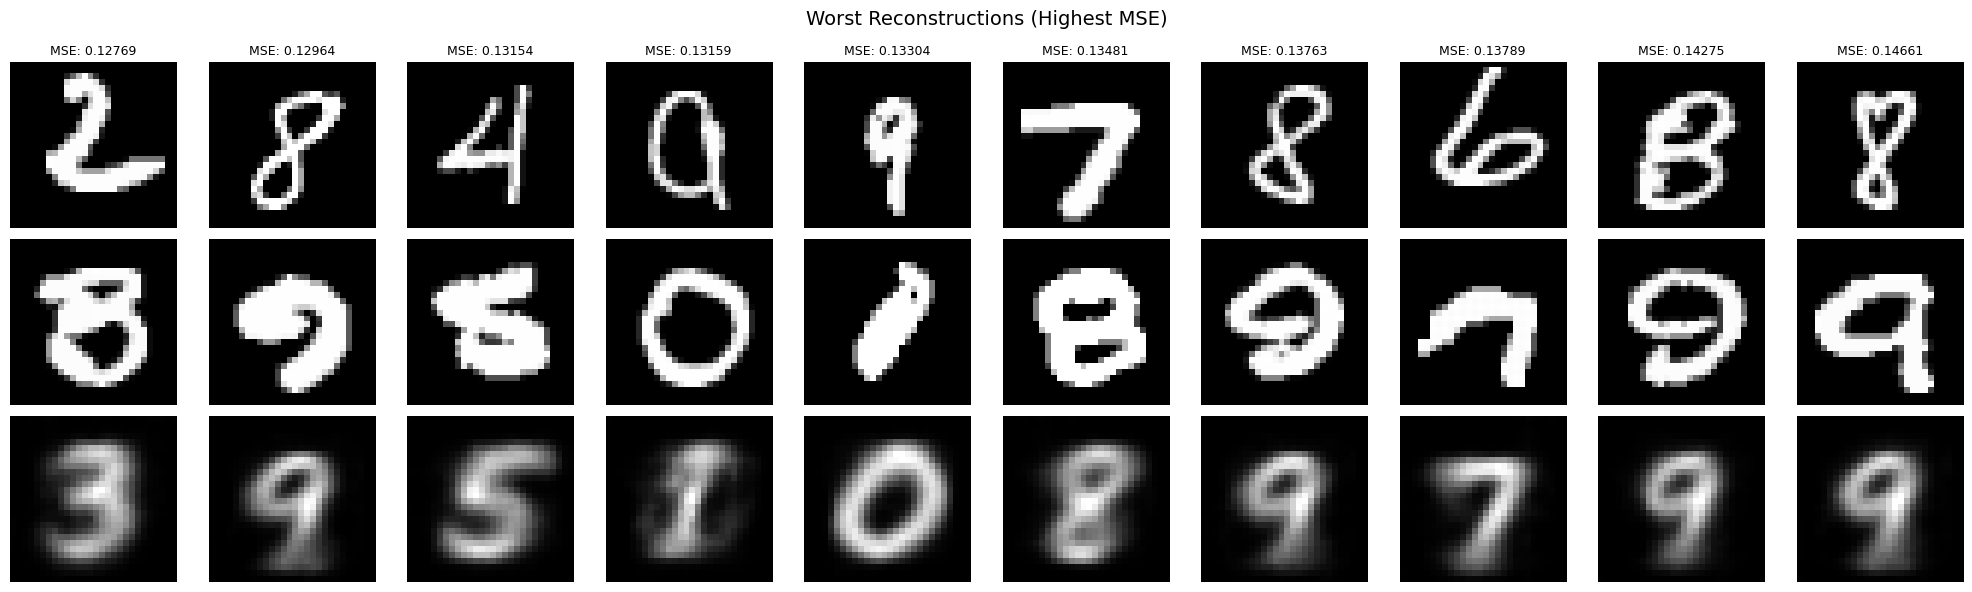

In [57]:
Show_Autoencoder_Reconstructions(Balthazar392_96_ND , validation_dataloader , next_digit = True , num_examples = 10)

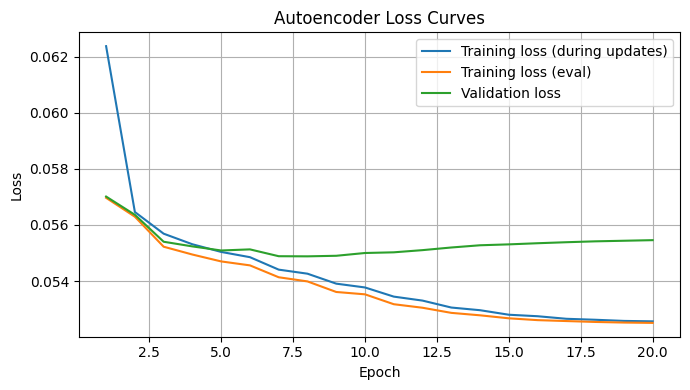

In [64]:
Balthazar392_128_ND_results = torch.load("Balthazar392_128_ND_results.pt" , map_location = "cpu")
Plot_Autoencoder_Curves(Balthazar392_128_ND_results)

#### Επίδοση του CNN (Kasper) στα Nest Digit Reconstructions.
Παρακάτω τρέχουμε δύο πειράματα, για το μεγαλύτερο και το μικρότερο μοντέλο που εκπαιδεύσαμε νωρίτερα.
##### Αποτελέσματα:
ΠΑρόλο του δεν φαινόταν κάποια μεγάλη διαφορά στο MSE, προκύπτει πως υπάρχει διαφορά μεταξύ των δύο μοντέλων. Το ΝΝ αποδίδει κατά 1,2% καλύτερα στα reconstructions του μεγαλύτερου μοντέλου.

In [59]:
Kasper_best_state = torch.load("Kasper_best_state.pt" , map_location = "cpu")
Balthazar392_96_ND_best_state = torch.load("Balthazar392_96_ND_best_state.pt" , map_location = "cpu")

Kasper_model = Kasper()
Kasper_model.load_state_dict(Kasper_best_state)
Kasper_model.eval()

Balthazar392_96_ND = Balthazar(channels = 8 , base = 96)
Balthazar392_96_ND.load_state_dict(Balthazar392_96_ND_best_state)
Balthazar392_96_ND.eval()

test_set = datasets.MNIST(root = root , train = False , download = True , transform = transform)

test_indices = np.arange(len(test_set))
next_digit_test_set = Next_Digit_Dataset(test_set , test_indices)

next_digit_test_dataloader = DataLoader(next_digit_test_set , batch_size = 512 , shuffle = False , num_workers = 0)

correct_recon = 0
correct_target = 0
total = 0

all_predictions_recon = []
all_predictions_target = []
all_labels_next = []

with torch.no_grad():
    for images , targets , labels in next_digit_test_dataloader:

        labels_next = (labels + 1) % 10

        recons = Balthazar392_96_ND(images)

        scores_recon = Kasper_model(recons)
        predictions_recon = scores_recon.argmax(dim = 1)

        scores_target = Kasper_model(targets)
        predictions_target = scores_target.argmax(dim = 1)

        correct_recon += (predictions_recon == labels_next).sum().item()
        correct_target += (predictions_target == labels_next).sum().item()
        total += labels.size(0)

        all_predictions_recon.append(predictions_recon.cpu())
        all_predictions_target.append(predictions_target.cpu())
        all_labels_next.append(labels_next.cpu())

recon_accuracy = correct_recon / total
target_accuracy = correct_target / total

all_predictions_recon = torch.cat(all_predictions_recon).numpy()
all_predictions_target = torch.cat(all_predictions_target).numpy()
all_labels_next = torch.cat(all_labels_next).numpy()

print("Kasper accuracy on next-digit target initial images:" , round(target_accuracy , 4))
print("Kasper accuracy on next-digit reconstrcutions:" , round(recon_accuracy , 4))

print("\nConfusion matrix (reconstructions):\n" , confusion_matrix(all_labels_next , all_predictions_recon))
print("\nClassification report (reconstructions):\n" , classification_report(all_labels_next , all_predictions_recon))


Kasper accuracy on next-digit target initial images: 0.9928
Kasper accuracy on next-digit reconstrcutions: 0.9807

Confusion matrix (reconstructions):
 [[ 996    1    0    2    0    2    1    0    3    4]
 [   0  974    0    1    0    0    0    1    1    3]
 [   2    0 1121    4    0    0    0    1    5    2]
 [   0    2    0 1020    0    1    0    0    2    7]
 [   3    0    0    1  965    0    7    1    2   31]
 [  11    1    0    6    0  949    0    1    3   11]
 [   3    1    0    0    6    0  877    1    1    3]
 [   2    7    2    5    0    0    0  939    1    2]
 [   4    0    2   19    0    0    0    0  999    4]
 [   4    1    0    0    0    0    0    2    0  967]]

Classification report (reconstructions):
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1009
           1       0.99      0.99      0.99       980
           2       1.00      0.99      0.99      1135
           3       0.96      0.99      0.98      1032
   

In [60]:
Kasper_best_state = torch.load("Kasper_best_state.pt" , map_location = "cpu")
Balthazar147_64_ND_best_state = torch.load("Balthazar147_64_ND_best_state.pt" , map_location = "cpu")

Kasper_model = Kasper()
Kasper_model.load_state_dict(Kasper_best_state)
Kasper_model.eval()

Balthazar147_64_ND = Balthazar(channels = 3 , base = 64)
Balthazar147_64_ND.load_state_dict(Balthazar147_64_ND_best_state)
Balthazar147_64_ND.eval()

test_set = datasets.MNIST(root = root , train = False , download = True , transform = transform)

test_indices = np.arange(len(test_set))
next_digit_test_set = Next_Digit_Dataset(test_set , test_indices)

next_digit_test_dataloader = DataLoader(next_digit_test_set , batch_size = 512 , shuffle = False , num_workers = 0)

correct_recon = 0
correct_target = 0
total = 0

all_predictions_recon = []
all_predictions_target = []
all_labels_next = []

with torch.no_grad():
    for images , targets , labels in next_digit_test_dataloader:

        labels_next = (labels + 1) % 10

        recons = Balthazar147_64_ND(images)

        scores_recon = Kasper_model(recons)
        predictions_recon = scores_recon.argmax(dim = 1)

        scores_target = Kasper_model(targets)
        predictions_target = scores_target.argmax(dim = 1)

        correct_recon += (predictions_recon == labels_next).sum().item()
        correct_target += (predictions_target == labels_next).sum().item()
        total += labels.size(0)

        all_predictions_recon.append(predictions_recon.cpu())
        all_predictions_target.append(predictions_target.cpu())
        all_labels_next.append(labels_next.cpu())

recon_accuracy = correct_recon / total
target_accuracy = correct_target / total

all_predictions_recon = torch.cat(all_predictions_recon).numpy()
all_predictions_target = torch.cat(all_predictions_target).numpy()
all_labels_next = torch.cat(all_labels_next).numpy()

print("Kasper accuracy on next-digit target initial images:" , round(target_accuracy , 4))
print("Kasper accuracy on next-digit reconstructions:" , round(recon_accuracy , 4))

print("\nConfusion matrix (reconstructions):\n" , confusion_matrix(all_labels_next , all_predictions_recon))
print("\nClassification report (reconstructions):\n" , classification_report(all_labels_next , all_predictions_recon))


Kasper accuracy on next-digit target initial images: 0.9928
Kasper accuracy on next-digit reconstructions: 0.9684

Confusion matrix (reconstructions):
 [[ 980    2    0    0    0    6    0    0   11   10]
 [   0  965    0    3    0    0    1    4    4    3]
 [   0    0 1122    3    1    0    0    0    5    4]
 [   1    1    0 1004    2    0    1    0   12   11]
 [   2    0    0    1  937    0   14    0    2   54]
 [  13    2    0    8    0  927    1    2   10   19]
 [   2    2    1    1    4    0  868    2    4    8]
 [   4   12    1    6    0    0    3  926    0    6]
 [   2    0    2   18    0    0    0    0 1000    6]
 [   4    3    0    1    3    0    1    6    1  955]]

Classification report (reconstructions):
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      1009
           1       0.98      0.98      0.98       980
           2       1.00      0.99      0.99      1135
           3       0.96      0.97      0.97      1032
   